# Unsupervised Clustering

1. No Labeled Data is Required
   
Why it matters: In many real-world scenarios, labeled data is unavailable, expensive, or time-consuming to obtain (e.g., medical diagnosis, user behavior).

How unsupervised learning helps: It can discover hidden patterns or groupings in raw data without needing predefined categories.

Example: Customer segmentation in marketing — you often don't have labels saying "high spender" or "loyal customer", but unsupervised learning can group customers based on behavior.

2. Reveals Natural Structure in Data
   
Why it matters: Understanding the underlying structure or distribution of data can be critical for decision-making, visualization, and pre-processing.

How unsupervised learning helps: Algorithms like K-Means or PCA find structure (e.g., clusters, directions of maximum variance) that can improve:

Feature engineering, Anomaly detection, Dimensionality reduction

Example: PCA reducing noise in images before using a supervised model.

In [ ]:
# Scratch

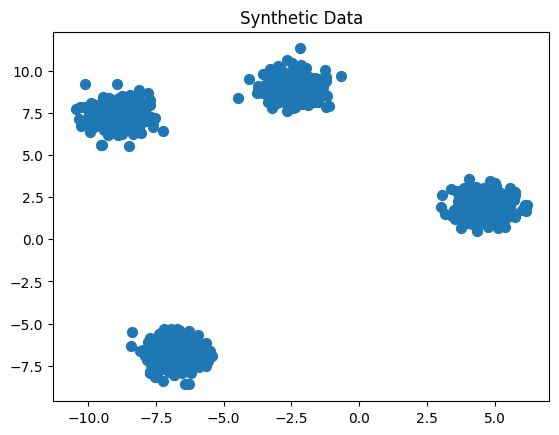

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic 2D data
from sklearn.datasets import make_blobs
X, y_true = make_blobs(n_samples=1000, centers=4, cluster_std=0.6, random_state=42)

plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Synthetic Data")
plt.show()


In [ ]:
Step 2: Initialize Random Centroids

What it does:
Randomly selects k points from the dataset X as the initial centroids.

Why we need it:
K-Means is an iterative algorithm that needs starting points (initial cluster centers).
The choice of centroids can affect the result, so it’s standard to choose randomly at first.


def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]


In [ ]:
Step 5: Convergence Check

What it does:
Checks whether the movement of centroids is smaller than a tiny threshold (tol), indicating convergence.

Why we need it:
To stop the algorithm when centroids no longer move (or move very little). Without this, we might loop forever.

def has_converged(old_centroids, new_centroids, tol=1e-4):
    return np.all(np.linalg.norm(old_centroids - new_centroids, axis=1) < tol)

In [ ]:
Step 6: Full K-Means Algorithm

What it does:
Combines all steps:
Initialize centroids

Loop:
1. Assign points to clusters
2. Update centroids
3. Check convergence
4. Stop when convergence is reached

Why we need it:
This is the complete K-Means loop. It's repeated until we reach stable cluster assignments.

def kmeans_from_scratch(X, k, max_iters=100):
    centroids = initialize_centroids(X, k)

    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)

        if has_converged(centroids, new_centroids):
            break
        centroids = new_centroids

    return centroids, labels


# INIITALIZE -> ASSIGN  -> UPDATE -> REPEAT

In [ ]:
def euclidean_distance(a, b):
    return np.linalg.norm(a - b, axis=1)

def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace=False)
    return X[indices]

def assign_clusters(X, centroids):
    clusters = []
    for point in X:
        distances = euclidean_distance(point, centroids)
        cluster = np.argmin(distances)
        clusters.append(cluster)
    return np.array(clusters)

def update_centroids(X, labels, k):
    new_centroids = []
    for i in range(k):
        cluster_points = X[labels == i]
        if len(cluster_points) == 0:
            # Randomly re-initialize if a cluster gets no points
            new_centroids.append(X[np.random.choice(len(X))])
        else:
            new_centroids.append(cluster_points.mean(axis=0))
    return np.array(new_centroids)

def has_converged(old_centroids, new_centroids, tol=1e-4):
    return np.all(np.linalg.norm(old_centroids - new_centroids, axis=1) < tol)

def kmeans_from_scratch(X, k, max_iters=100):
    centroids = initialize_centroids(X, k)

    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)

        if has_converged(centroids, new_centroids):
            break
        centroids = new_centroids

    return centroids, labels


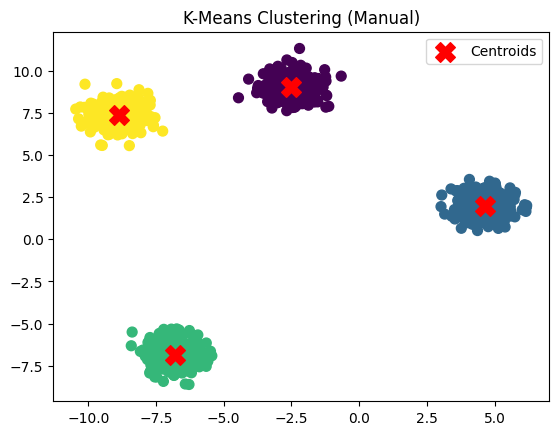

In [ ]:
k = 4
centroids, labels = kmeans_from_scratch(X, k)

# Plot results
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title("K-Means Clustering (Manual)")
plt.legend()
plt.show()


In [ ]:
# Elbow method

In [ ]:
# K-Means tries to minimize inertia — the tighter the clusters, the better the fit.
# The Elbow Method uses inertia values for different values of k to help find the optimal number of clusters.

# The function for elbow computes the inertia (also called within-cluster sum of squares, or WCSS) for a K-Means result.
# Inertia measures how tight the clusters are — it is the sum of squared distances between each point and the centroid of its assigned cluster.

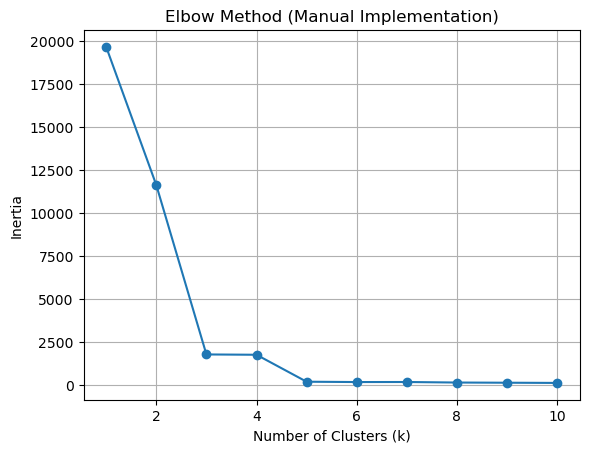

In [ ]:
def compute_inertia(X, labels, centroids):
    inertia = 0
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        inertia += ((cluster_points - centroids[i])**2).sum()
    return inertia

# For each point in the cluster:

# 1. Compute the squared distance from the point to its cluster centroid
# 2. Sum these distances for the cluster
# 3. Add that sum to the total inertia


inertias = []
ks = range(1, 11)
for k in ks:
    c, l = kmeans_from_scratch(X, k)
    inertias.append(compute_inertia(X, l, c))

plt.plot(ks, inertias, marker='o')
plt.title("Elbow Method (Manual Implementation)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


# Inbuilt function

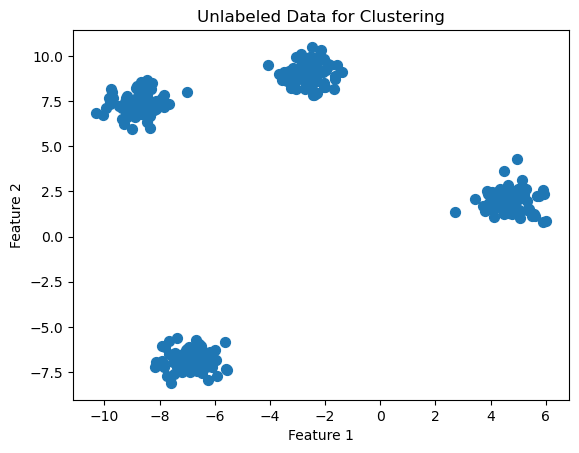

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Create synthetic dataset
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Plot the data
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Unlabeled Data for Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


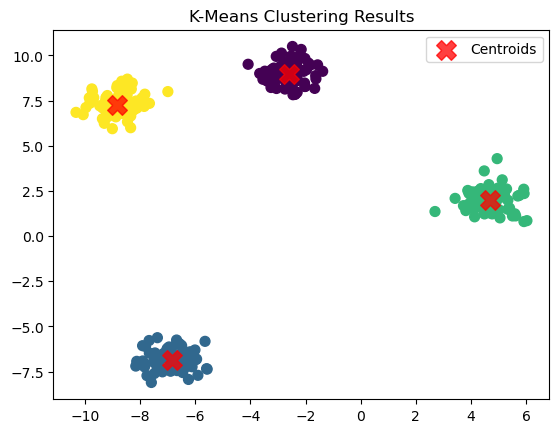

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')
plt.title("K-Means Clustering Results")
plt.legend()
plt.show()


C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

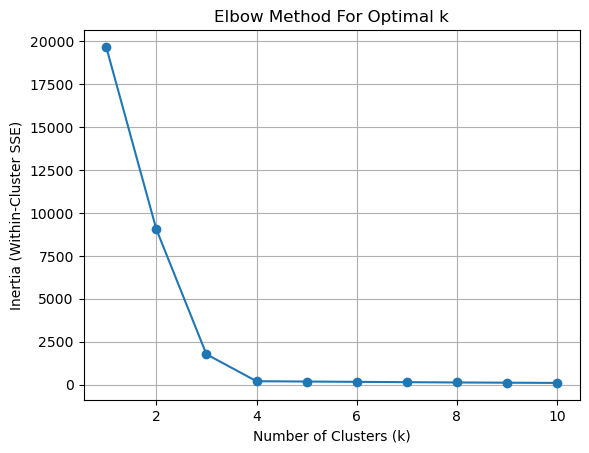

In [ ]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-Cluster SSE)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()


✅ Animation saved successfully!


In [ ]:
# using silhoutte score

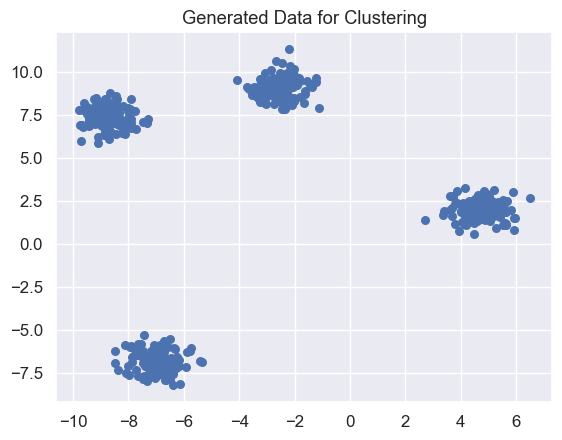

K=2 => Silhouette Score: 0.6187
K=3 => Silhouette Score: 0.8021
K=4 => Silhouette Score: 0.8757
K=5 => Silhouette Score: 0.7496
K=6 => Silhouette Score: 0.6040
K=7 => Silhouette Score: 0.4855
K=8 => Silhouette Score: 0.4783
K=9 => Silhouette Score: 0.4694


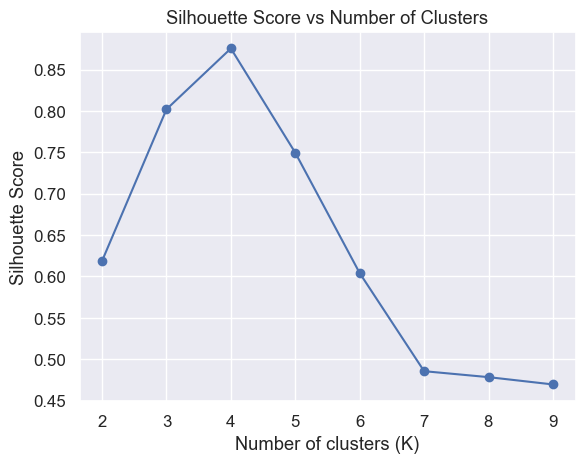

Optimal K based on silhouette score = 4


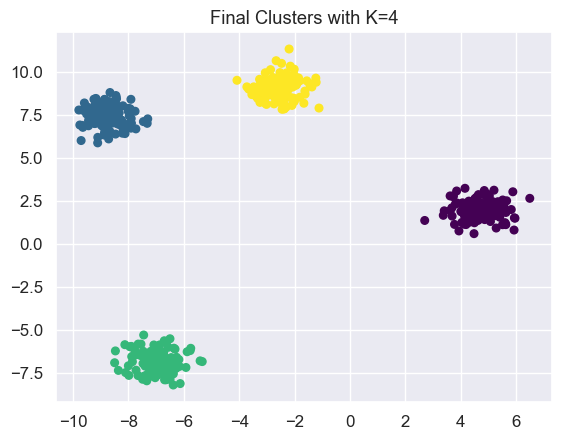

In [ ]:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 2: Generate synthetic data
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.6, random_state=42)

# Optional: visualize the data
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Generated Data for Clustering")
plt.show()


# Step 3: Try different K values and compute Silhouette Scores
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)
    print(f"K={k} => Silhouette Score: {sil_score:.4f}")


# Step 4: Plot Silhouette Scores vs Number of Clusters
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.grid(True)
plt.show()


# Step 5: Apply KMeans with optimal K (e.g., where silhouette is highest)
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"Optimal K based on silhouette score = {optimal_k}")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
final_labels = kmeans_final.fit_predict(X)

# Visualize final clusters
plt.scatter(X[:, 0], X[:, 1], c=final_labels, cmap='viridis', s=30)
plt.title(f"Final Clusters with K={optimal_k}")
plt.show()


In [ ]:
# Just an animation to show
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.datasets import make_blobs
from sklearn.cluster import MiniBatchKMeans
import numpy as np
#pip install pillow

# Generate synthetic data
X, _ = make_blobs(n_samples=1000, centers=10, random_state=42)

fig, ax = plt.subplots()
kmeans = MiniBatchKMeans(n_clusters=3, random_state=42, batch_size=50)

centroids = []
labels_list = []

# Run multiple partial fits to simulate steps
for _ in range(20):
    kmeans.partial_fit(X)
    centroids.append(kmeans.cluster_centers_.copy())
    labels_list.append(kmeans.predict(X))

def animate(i):
    ax.clear()
    ax.scatter(X[:, 0], X[:, 1], c=labels_list[i], cmap='viridis', s=20)
    ax.scatter(*centroids[i].T, c='red', marker='x', s=100)
    ax.set_title(f"Iteration {i+1}")

ani = FuncAnimation(fig, animate, frames=len(centroids), interval=800)

# === OR save as GIF (requires pillow) ===
ani.save("kmeans_animation.gif", writer=PillowWriter(fps=1))

plt.close()  # Avoid duplicate frame in output
print("✅ Animation saved successfully!")


K = 2 => Inertia: 222.36, Silhouette: 0.5818
K = 3 => Inertia: 191.02, Silhouette: 0.4799
K = 4 => Inertia: 114.35, Silhouette: 0.3850
K = 5 => Inertia: 91.05, Silhouette: 0.3450
K = 6 => Inertia: 81.55, Silhouette: 0.3339
K = 7 => Inertia: 80.78, Silhouette: 0.2664
K = 8 => Inertia: 64.43, Silhouette: 0.3416
K = 9 => Inertia: 55.71, Silhouette: 0.3244


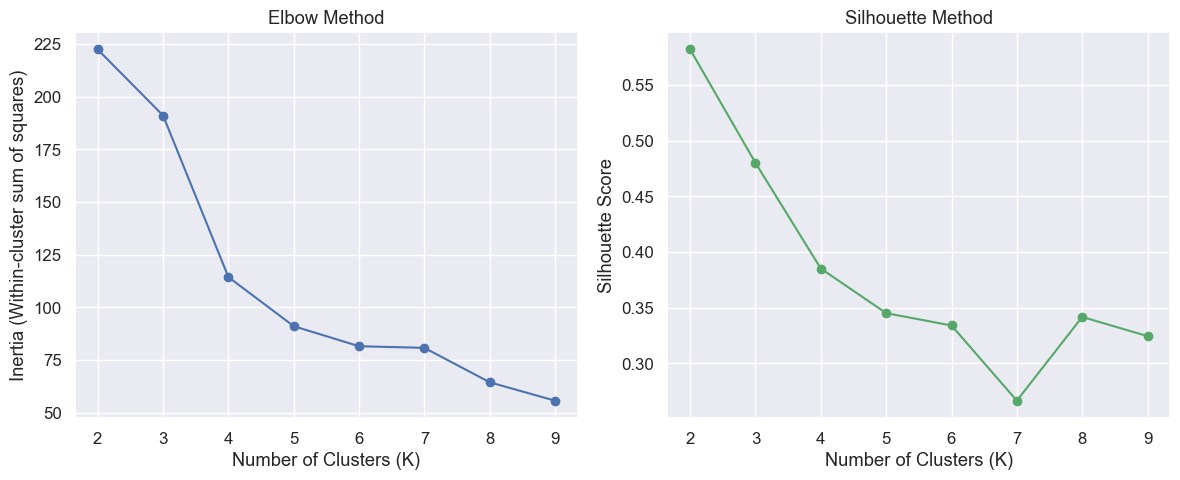


✅ Optimal K based on silhouette score: 2


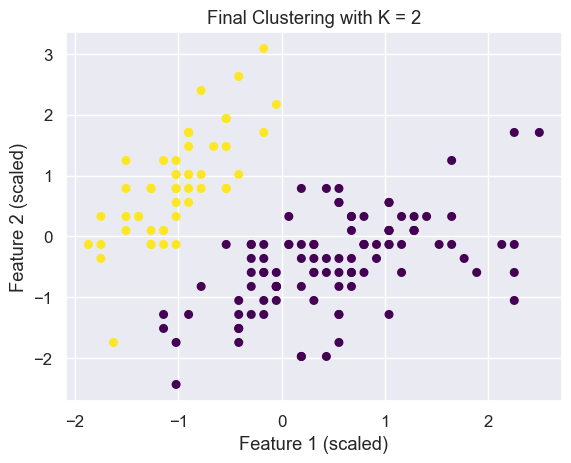

In [ ]:
# local optimum !

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load and scale the data
iris = load_iris()
X = StandardScaler().fit_transform(iris.data)

# Initialize lists
inertias = []               # For Elbow Method
silhouette_scores = []      # For Silhouette Method
K_range = range(2, 10)

# Loop through possible K values
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(X)

    # Elbow Method: store inertia
    inertias.append(kmeans.inertia_)

    # Silhouette Method: store silhouette score
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)
    print(f"K = {k} => Inertia: {kmeans.inertia_:.2f}, Silhouette: {sil_score:.4f}")

# Plot Elbow Curve
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, 'go-')
plt.title('Silhouette Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

# Optimal K based on silhouette
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✅ Optimal K based on silhouette score: {optimal_k}")

# Final Clustering with optimal_k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
final_labels = kmeans_final.fit_predict(X)

# Visualize clusters (first 2 PCA components or just feature 0 and 1)
plt.scatter(X[:, 0], X[:, 1], c=final_labels, cmap='viridis', s=30)
plt.title(f"Final Clustering with K = {optimal_k}")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.grid(True)
plt.show()


Comment this !
"Silhouette Score tells you how good the grouping is geometrically — not whether the number of clusters matches the real-world classes.

In [ ]:
# Example of using datasets

C:\Users\fedex\anaconda3\envs\ABMLLM\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


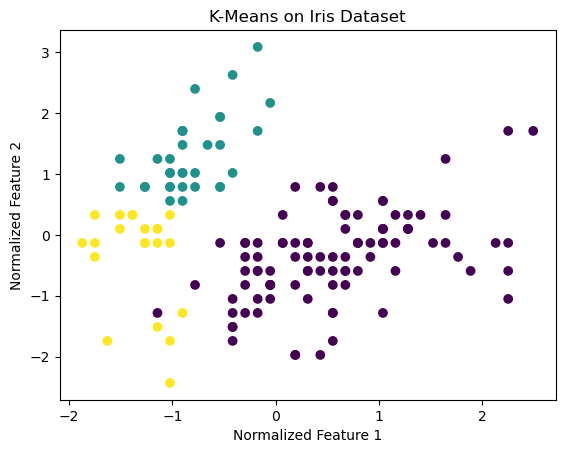

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)

kmeans_iris = KMeans(n_clusters=3, random_state=42)
labels = kmeans_iris.fit_predict(X_iris)

plt.scatter(X_iris[:, 0], X_iris[:, 1], c=labels, cmap='viridis')
plt.title("K-Means on Iris Dataset")
plt.xlabel("Normalized Feature 1")
plt.ylabel("Normalized Feature 2")
plt.show()


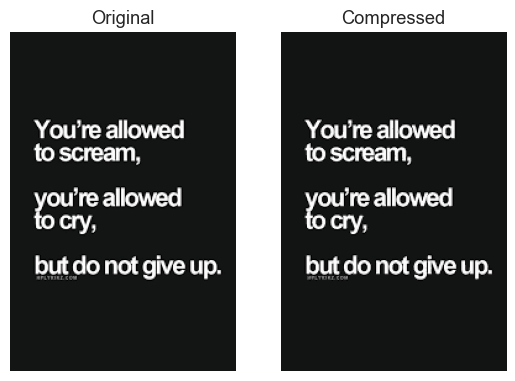

Original image colors: 48
Compressed image colors: 8


In [ ]:
#  Image Compression Using K-Means
!pip install scikit-image

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from skimage import io
import numpy as np

image = io.imread('data.png')
pixels = image.reshape(-1, 3)

kmeans = KMeans(n_clusters=8, random_state=0).fit(pixels)
compressed_pixels = kmeans.cluster_centers_[kmeans.labels_].reshape(image.shape).astype('uint8')

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Compressed")
plt.imshow(compressed_pixels)
plt.axis('off')

plt.show()

# Number of unique colors in original image
original_colors = np.unique(image.reshape(-1, 3), axis=0)
print("Original image colors:", len(original_colors))

# Number of unique colors in compressed image
compressed_colors = np.unique(compressed_pixels.reshape(-1, 3), axis=0)
print("Compressed image colors:", len(compressed_colors))

In [1]:
# Document clustering

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

docs = [
    "The stock market crashed yesterday",
    "Apple launched a new iPhone",
    "The economy is improving",
    "Google released a new AI model",
    "The sports team won their game"
]

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(docs)

kmeans = KMeans(n_clusters=5, random_state=42).fit(X)

for i, doc in enumerate(docs):
    print(f"Cluster {kmeans.labels_[i]}: {doc}")


Cluster 2: The stock market crashed yesterday
Cluster 0: Apple launched a new iPhone
Cluster 4: The economy is improving
Cluster 3: Google released a new AI model
Cluster 1: The sports team won their game


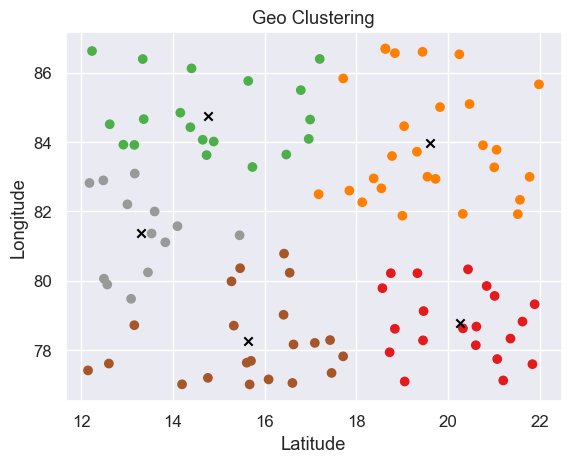

In [ ]:
import numpy as np

# Some lat/long data
coords = np.random.rand(100, 2) * [10, 10] + [12, 77]

kmeans = KMeans(n_clusters=5, random_state=0).fit(coords)
plt.scatter(coords[:, 0], coords[:, 1], c=kmeans.labels_, cmap='Set1')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', marker='x')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('Geo Clustering')
plt.grid(True)
plt.show()


###  RFM Scoring Overview

RFM is a customer segmentation technique that evaluates customer behavior based on:

| Metric     | Description |
|------------|-------------|
| **Recency (R)** | How recently a customer made a purchase (lower is better) |
| **Frequency (F)** | How often a customer makes purchases (higher is better) |
| **Monetary (M)** | How much a customer spends (higher is better) |

Each customer is scored from **1 (worst)** to **5 (best)** on each of the R, F, and M dimensions based on **quantile ranks**.

### Sample RFM Score Interpretation:

| RFM Score | Segment               |
|-----------|------------------------|
| 555       | Champions              |
| 511       | New Customers          |
| 155       | High Spenders, New     |
| 111       | Churned/Lost Customers |


In [ ]:
Example: Customer Segmentation in Retail

You work for an e-commerce or retail company and want to group customers based on their purchasing behavior,
so you can tailor marketing strategies (e.g., discounts, recommendations, email campaign)

Why Use K-Means:

You don’t have labels like “VIP” or “occasional buyer”.
But you do have features like:

Total money spent
Frequency of purchases
Recency (how recently they bought something)

### DATASET:

### This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.The company mainly sells unique all-occasion gifts. Many customers of the company are wholesalers.


In [ ]:
import sys
import pandas as pd
import numpy as np
import plotly.express as px
import plotly as py
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from PIL import Image

import pandas as pd
from pathlib import Path

import calendar
!pip install termcolor
from termcolor import colored
from IPython.display import HTML

import warnings
warnings.filterwarnings("ignore")
py.offline.init_notebook_mode(connected = True)

#pip3 install plotly

In [ ]:
# Step 1 Reading data and preprocessing
# pip or conda to install openpyxl
df= pd.read_excel(r"C:\Users\fedex\Downloads\JARO DAY 1\12042026\Online_Retail.xlsx")
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
print("Number of rows in dataset is: ", df.shape[0])
print("Number of columns in dataset is: ", df.shape[1])

Number of rows in dataset is:  541909
Number of columns in dataset is:  8


##  Wrangle, prepare, cleanse the data

In [ ]:
print('Duplicate entries: {}'.format(df.duplicated().sum()))
print('{}% rows are duplicate.'.format(round((df.duplicated().sum()/df.shape[0])*100),2))

#Remove duplicate data
df.drop_duplicates(inplace = True)

Duplicate entries: 5268
1% rows are duplicate.


In [ ]:
# Consistent formatting
df['CustomerID'] = df['CustomerID'].astype(str)

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice
count,536641.000000,536641,536641.000000
mean,9.620029,2011-07-04 08:57:06.087421952,4.632656
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 10:52:00,1.250000
50%,3.000000,2011-07-19 14:04:00,2.080000
75%,10.000000,2011-10-18 17:05:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,219.130156,NaN,97.233118


In [ ]:
pd.DataFrame([{'products': len(df['StockCode'].value_counts()),
               'transactions': len(df['InvoiceNo'].value_counts()),
               'customers': len(df['CustomerID'].unique().tolist()),
              }], columns = ['products', 'transactions', 'customers'], index = ['quantity'])

,products,transactions,customers
quantity,4070,25900,4373


## Missing values
### Removing cancelled orders from the data. Filtering transaction with invoice number started with letter 'C' and missing Customer ID


In [ ]:
## Removing cancelled orders

cancelled = df['InvoiceNo'].astype(str).str.contains('C')
cancelled.fillna(0, inplace=True)
cancelled = cancelled.astype(int)
cancelled.value_counts()

InvoiceNo
0    527390
1      9251
Name: count, dtype: int64

In [ ]:
df['order_canceled'] = cancelled
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,order_canceled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0


In [ ]:
n1 = df['order_canceled'].value_counts()[1]
n2 = df.shape[0]
print("Number of cancelled transactions:", n1)
print('Number of orders canceled: {}/{} ({:.2f}%) '.format(n1, n2, n1/n2*100))
df = df[df['order_canceled'] == 0]

Number of cancelled transactions: 9251
Number of orders canceled: 9251/536641 (1.72%) 


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,order_canceled
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0


In [ ]:
df = df[df['CustomerID'].notna()]

In [ ]:
print("Total number of transaction with negative quantity:", df[df['Quantity'] <= 0 ]['Quantity'].count())
print("Precentage of transactions with zero or negative quantity" ,round(len(df[df['Quantity']<=0])/len(df)*100, 2),"%")
print("Total number of transaction with negative Price:", df[df['UnitPrice'] <= 0 ]['UnitPrice'].count())
print("Precentage of transactions with zero or negative price" ,round(len(df[df['UnitPrice']<=0])/len(df)*100, 2),"%")

Total number of transaction with negative quantity: 1336
Precentage of transactions with zero or negative quantity 0.25 %
Total number of transaction with negative Price: 2512
Precentage of transactions with zero or negative price 0.48 %


In [ ]:
df = df[(df['UnitPrice'] > 0) & (df['Quantity'] > 0)]

In [ ]:
print("Number of rows in dataset is: ", df.shape[0])
print("Number of columns in dataset is: ", df.shape[1])

Number of rows in dataset is:  524878
Number of columns in dataset is:  9


# ---- End the data cleaning----

# Step 2 Create Recency Frequency Monetary (RFM) table

RFM is a basic customer segmentation algorithm based on their purchasing behaviour. The behaviour is identified by using only three customer data points:

Recency: the recency of purchase/ How many days ago was their last purchase?

Frequency: the frequency of purchases/ total number of purchases/How many times has the customer purchased from our store?

Monetary: the mean monetary value of each purchase/the amount they have spent/How much has this customer spent?  Again limit to last two years – or take all time


The RFM Analysis will help the businesses to segment their customer base into different homogenous groups so that they can engage with each group
with different targeted marketing strategies. Sometime RMF is also used to identify the High-Value Customers (HVCs)

In [ ]:
print('Start date:' , df['InvoiceDate'].min())
print('End date:' , df['InvoiceDate'].max())

Start date: 2010-12-01 08:26:00
End date: 2011-12-09 12:50:00


In [ ]:
# Create revenue colummn
df['Revenue'] = df['UnitPrice'] * df['Quantity']
# Convert to show date only
from datetime import datetime
df["InvoiceDate"] = df["InvoiceDate"].dt.date

In [ ]:
import datetime as dt
snapshot_date = max(df.InvoiceDate) + dt.timedelta(days=1)
print(snapshot_date)

2011-12-10


In [ ]:
# RFM table
# Aggregate data by each customer
rfm = df.groupby('CustomerID').agg({'InvoiceDate': lambda x: (snapshot_date - x.max()).days, 'InvoiceNo': lambda x: len(x), 'Revenue': lambda x: x.sum()}).reset_index()
rfm['InvoiceDate'] = rfm['InvoiceDate'].astype(int)

# Rename columns
rfm.rename(columns={'InvoiceDate': 'Recency',
                         'InvoiceNo': 'Frequency',
                         'Revenue': 'MonetaryValue'}, inplace=True)

In [ ]:
rfm.head()

,CustomerID,Recency,Frequency,MonetaryValue
0,12346.0,326,1,77183.60
1,12347.0,3,182,4310.00
2,12348.0,76,31,1797.24
3,12349.0,19,73,1757.55
4,12350.0,311,17,334.40


Right now, the dataset consists of recency, frequency, and monetary value column.
But we cannot use the dataset yet ( we have to preprocess the data more.)

# Manage Skewness and Scaling
We have to make sure that the data meet these assumptions:

The data should meet assumptions where the variables are not skewed and have the same mean and variance.
Because of that, we have to manage the skewness of the variables. Here are the visualizations of each variable.

# Explore the data
Recency, Frequency,MonetaryValue distributions

In [ ]:
# fig, ax = plt.subplots(1, 3, figsize=(15,3))
# sns.distplot(rfm['Recency'], ax=ax[0])
# sns.distplot(rfm['Frequency'], ax=ax[1])
# sns.distplot(rfm['MonetaryValue'], ax=ax[2])
# plt.tight_layout()
# plt.show()

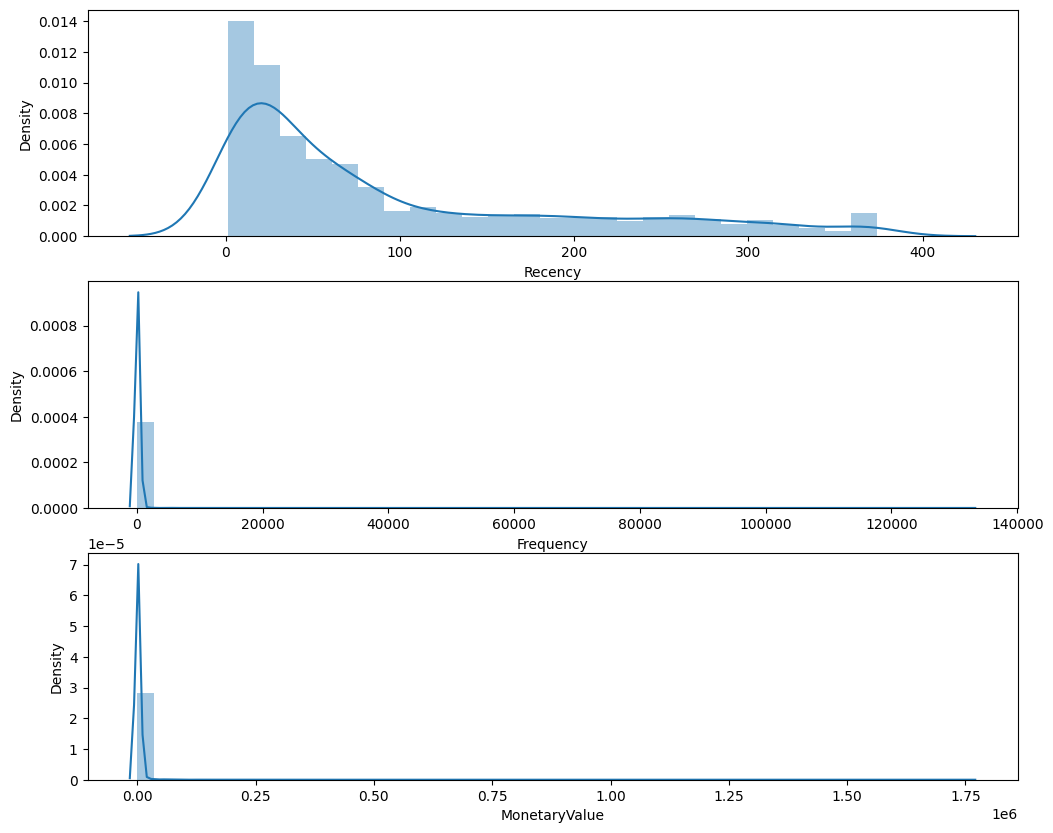

In [ ]:
plt.figure(figsize=(12,10))

# Plot recency distribution
plt.subplot(3, 1, 1); sns.distplot(rfm['Recency'])

# Plot frequency distribution
plt.subplot(3, 1, 2); sns.distplot(rfm['Frequency'])

# Plot monetary value distribution
plt.subplot(3, 1, 3); sns.distplot(rfm['MonetaryValue'])

# Show the plot
plt.show()

# FYI:

# Why do we apply transformations?
Most machine learning algorithms (like K-Means) assume that:

Features are normally distributed (bell curve)
There’s no skewness (i.e., symmetry around the mean)

But in real datasets (especially Recency, Frequency, and MonetaryValue):

Values are usually highly skewed (e.g., many customers buy little, few buy a lot)
So, we apply transformations to reduce skew and make data closer to normal distribution



# Skewness Recap
Skewness measures the asymmetry of a distribution.

Positive skew = long right tail (common in monetary and frequency data)
Negative skew = long left tail

Ideal skew ≈ 0 (closer to symmetry)

In [ ]:
from scipy import stats
def analyze_skewness(x):
    fig, ax = plt.subplots(2, 2, figsize=(5,5))
    sns.distplot(rfm[x], ax=ax[0,0])
    sns.distplot(np.log(rfm[x]), ax=ax[0,1])
    sns.distplot(np.sqrt(rfm[x]), ax=ax[1,0])
    sns.distplot(stats.boxcox(rfm[x])[0], ax=ax[1,1])
    plt.tight_layout()
    plt.show()

#     print(rfm[x].skew().round(2))
#     print(np.log(rfm[x]).skew().round(2))
#     print(np.sqrt(rfm[x]).skew().round(2))
#     print(pd.Series(stats.boxcox(rfm[x])[0]).skew().round(2))

    print('Log Transform : The skew coefficient of', rfm[x].skew().round(2), 'to', np.log(rfm[x]).skew().round(2))
    print('Square Root Transform : The skew coefficient of', rfm[x].skew().round(2), 'to', np.sqrt(rfm[x]).skew().round(2))
    print('Box-Cox Transform : The skew coefficient of', rfm[x].skew().round(2), 'to', pd.Series(stats.boxcox(rfm[x])[0]).skew().round(2))

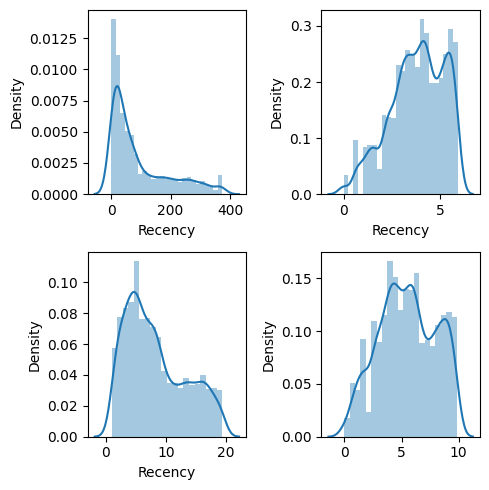

Log Transform : The skew coefficient of 1.25 to -0.47
Square Root Transform : The skew coefficient of 1.25 to 0.6
Box-Cox Transform : The skew coefficient of 1.25 to -0.06


In [ ]:
analyze_skewness('Recency')

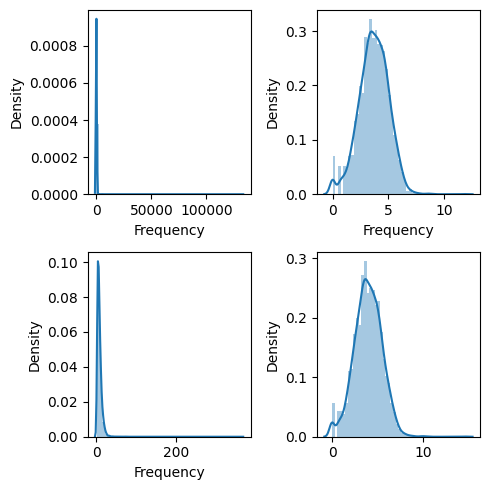

Log Transform : The skew coefficient of 64.67 to -0.17
Square Root Transform : The skew coefficient of 64.67 to 23.58
Box-Cox Transform : The skew coefficient of 64.67 to 0.01


In [ ]:
analyze_skewness('Frequency')

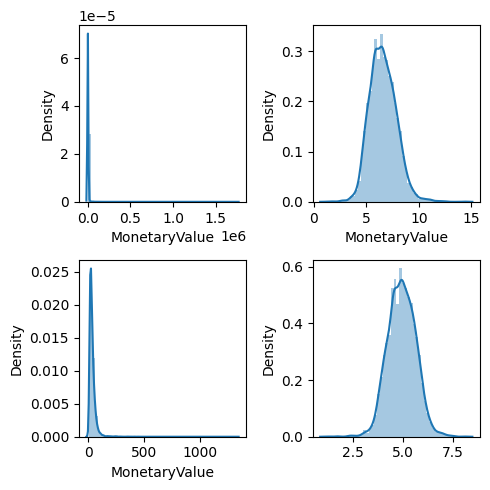

Log Transform : The skew coefficient of 56.65 to 0.43
Square Root Transform : The skew coefficient of 56.65 to 14.0
Box-Cox Transform : The skew coefficient of 56.65 to -0.02


In [ ]:
analyze_skewness('MonetaryValue')

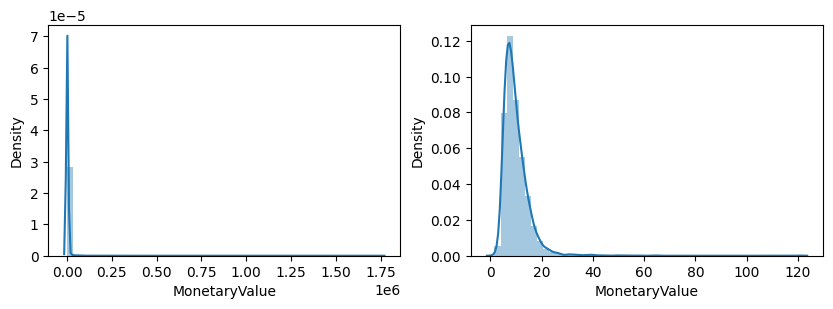

56.65
4.73


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10,3))
sns.distplot(rfm['MonetaryValue'], ax=ax[0])
sns.distplot(np.cbrt(rfm['MonetaryValue']), ax=ax[1])
plt.show()
print(rfm['MonetaryValue'].skew().round(2))
print(np.cbrt(rfm['MonetaryValue']).skew().round(2))

In [ ]:
pd.Series(np.cbrt(rfm['MonetaryValue'])).values

array([ 42.57699537,  16.27392924,  12.15818345, ...,  12.69410105,
        12.24781024, 120.61952546])

###  Cross Checking

Recency Summary:
count    4339.000000
mean       93.038258
std       100.010502
min         1.000000
25%        18.000000
50%        51.000000
75%       142.500000
max       374.000000
Name: Recency, dtype: float64

Frequency Summary:
count      4339.000000
mean        120.967504
std        2018.000172
min           1.000000
25%          17.000000
50%          41.000000
75%          98.000000
max      132186.000000
Name: Frequency, dtype: float64

MonetaryValue Summary:
count    4.339000e+03
mean     2.452664e+03
std      2.808606e+04
min      3.750000e+00
25%      3.065050e+02
50%      6.685800e+02
75%      1.660890e+03
max      1.754902e+06
Name: MonetaryValue, dtype: float64
Minimum Values:
Recency: 1
Frequency: 1
MonetaryValue: 3.75


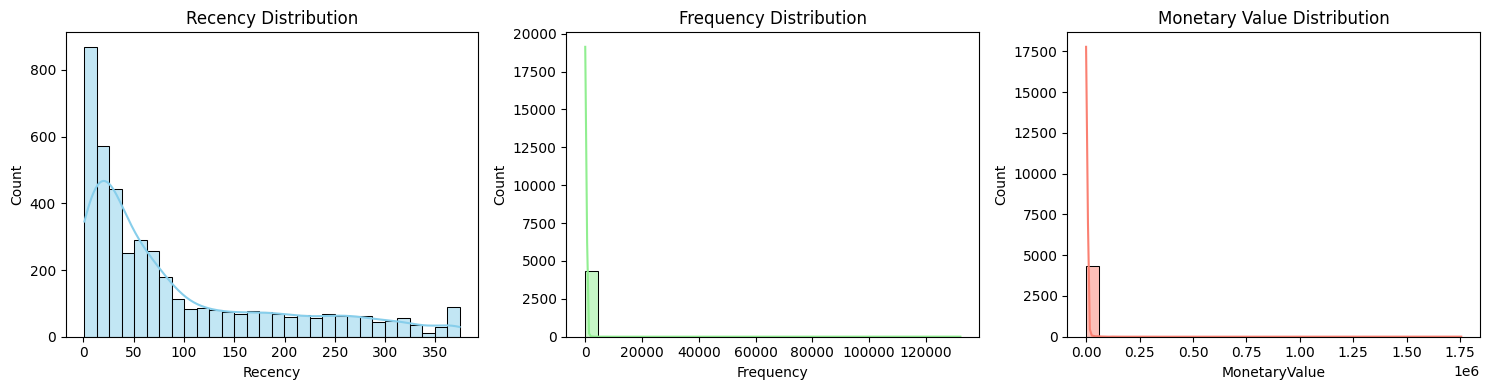

(array([7.08497169, 5.88523803, 5.45579225, ..., 5.52146995, 5.46702928,
        8.07749342]),
 -0.08972315821593127)

In [ ]:
print("Recency Summary:")
print(rfm['Recency'].describe())

print("\nFrequency Summary:")
print(rfm['Frequency'].describe())

print("\nMonetaryValue Summary:")
print(rfm['MonetaryValue'].describe())


print("Minimum Values:")
print("Recency:", rfm['Recency'].min())
print("Frequency:", rfm['Frequency'].min())
print("MonetaryValue:", rfm['MonetaryValue'].min())

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.subplot(1, 3, 1)
sns.histplot(rfm['Recency'], bins=30, kde=True, color='skyblue')
plt.title('Recency Distribution')

plt.subplot(1, 3, 2)
sns.histplot(rfm['Frequency'], bins=30, kde=True, color='lightgreen')
plt.title('Frequency Distribution')

plt.subplot(1, 3, 3)
sns.histplot(rfm['MonetaryValue'], bins=30, kde=True, color='salmon')
plt.title('Monetary Value Distribution')

plt.tight_layout()
plt.show()


from scipy.stats import boxcox

# Try on Recency (should work)
boxcox(rfm['Recency'])

# Try on MonetaryValue (should fail)
boxcox(rfm['MonetaryValue'])  #  This will throw a ValueError if data has negative values in it

In [ ]:
# Set the Numbers
from scipy import stats
customers_fix = pd.DataFrame()
customers_fix["Recency"] = stats.boxcox(rfm['Recency'])[0]
customers_fix["Frequency"] = stats.boxcox(rfm['Frequency'])[0]
customers_fix["MonetaryValue"] = pd.Series(np.cbrt(rfm['MonetaryValue'])).values
#customers_fix["MonetaryValue"] = stats.boxcox(rfm['MonetaryValue'])[0]
customers_fix.tail()

,Recency,Frequency,MonetaryValue
4334,8.082516,2.013090,4.323541
4335,2.464211,2.595151,5.625753
4336,1.550855,7.392322,12.694101
4337,5.147101,4.577527,12.247810
4338,0.000000,14.569197,120.619525


Each variable don’t have the same mean and variance.
We have to normalize it.
To normalize, we can use StandardScaler object from scikit-learn library to do it.
The code will look like this,

In [ ]:
# Import library
from sklearn.preprocessing import StandardScaler
# Initialize the Object
scaler = StandardScaler()
# Fit and Transform The Data
scaler.fit(customers_fix)
customers_normalized = scaler.transform(customers_fix)
# Assert that it has mean 0 and variance 1
print(customers_normalized.mean(axis = 0).round(2))
print(customers_normalized.std(axis = 0).round(2))

[-0. -0. -0.]
[1. 1. 1.]


In [ ]:
# pd.DataFrame(customers_normalized).head()
pd.DataFrame(customers_normalized).tail()

,0,1,2
4334,1.049851,-1.289677,-1.067053
4335,-1.225255,-0.902575,-0.817688
4336,-1.595114,2.287802,0.535859
4337,-0.138831,0.415812,0.450397
4338,-2.223125,7.060810,21.202932


Finally, we can do clustering using that data.

# Step 3 Model - Clustering with K-means algorithm
    
To make segmentation from the data, we can use the K-Means algorithm to do this.

K-Means algorithm is an unsupervised learning algorithm that uses the geometrical principle to determine which cluster belongs to the data.
By determine each centroid, we calculate the distance to each centroid.
Each data belongs to a centroid if it has the smallest distance from the other.
It repeats until the next total of the distance doesn’t have significant changes than before.

Determine the Optimal K
To make our clustering reach its maximum performance, we have to determine which hyperparameter fits to the data.
To determine which hyperparameter is the best for our model and data, we can use the elbow method to decide.

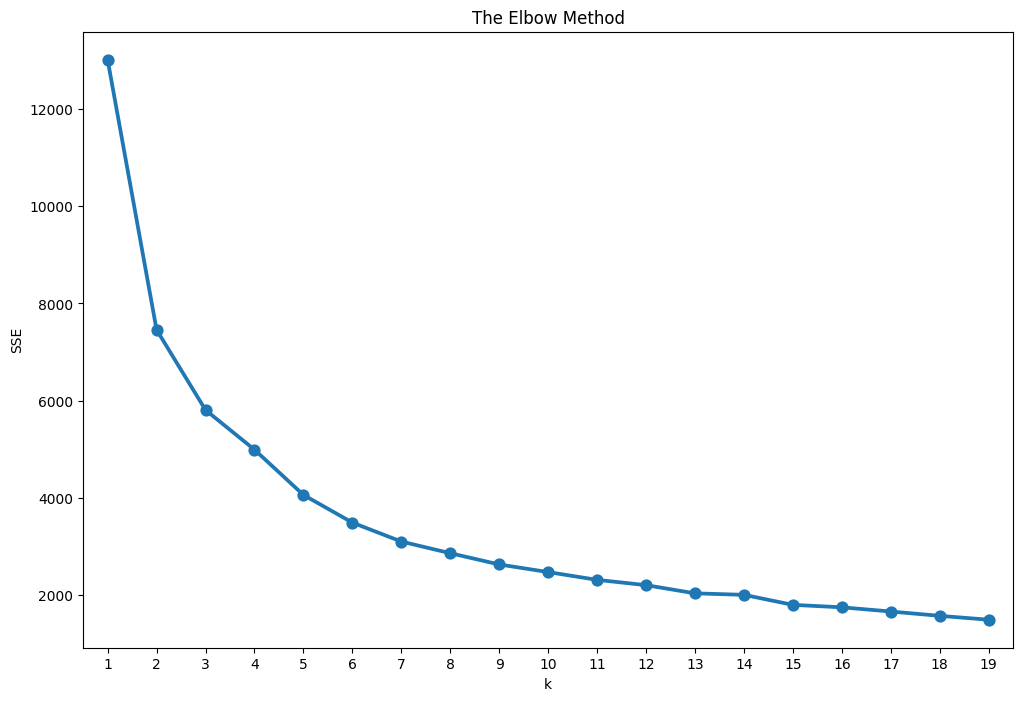

In [ ]:
plt.figure(figsize=(12,8))

from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
K = range(1, 20)

distortions = []
inertias = []
mapping1 = {}
sse = {}
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(customers_normalized)

    distortions.append(sum(np.min(cdist(customers_normalized, kmeans.cluster_centers_,
                                        'euclidean'), axis=1)) / customers_normalized.shape[0])
    inertias.append(kmeans.inertia_)

    mapping1[k] = sum(np.min(cdist(customers_normalized, kmeans.cluster_centers_,
                                   'euclidean'), axis=1)) / customers_normalized.shape[0]

    sse[k] = kmeans.inertia_ # SSE to closest cluster centroid

plt.title('The Elbow Method')
plt.xlabel('k')
plt.ylabel('SSE')
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

In [ ]:
for key, val in mapping1.items():
    print(f'{key} : {val}')

1 : 1.4757164433571686
2 : 1.1026598970122181
3 : 0.9618525233930552
4 : 0.8846886109957599
5 : 0.8387708187380395
6 : 0.7677507050533026
7 : 0.7218352296146067
8 : 0.6969787713086969
9 : 0.6616240143858243
10 : 0.6405728935328615
11 : 0.6181765103292052
12 : 0.5982792129512883
13 : 0.5823198079620172
14 : 0.5721132161961168
15 : 0.5662445381093801
16 : 0.5601688328759976
17 : 0.5425554276016722
18 : 0.5261621044832003
19 : 0.5189601250036743


# Fit the model - 3 cluster

In [ ]:
model = KMeans(n_clusters=3, random_state=42)
model.fit(customers_normalized)
model.labels_.shape

(4339,)

In [ ]:
rfm.shape

(4339, 4)

In [ ]:
## By fitting the model, we can have clusters where each data belongs. By that, we can analyze the data.

rfm["Cluster"] = model.labels_
rfm.head()

,CustomerID,Recency,Frequency,MonetaryValue,Cluster
0,12346.0,326,1,77183.60,2
1,12347.0,3,182,4310.00,2
2,12348.0,76,31,1797.24,1
3,12349.0,19,73,1757.55,1
4,12350.0,311,17,334.40,0


In [ ]:
rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'MonetaryValue':['mean', 'count']}).round(1)

Recency Frequency MonetaryValue      
           mean      mean          mean count
Cluster                                      
0         186.1      19.8         403.1  1651
1          42.2      65.5        1024.3  1916
2          20.3     474.9       10381.0   772

# Fit the model - 4 cluster

In [ ]:
model = KMeans(n_clusters=4, random_state=42)
model.fit(customers_normalized)
model.labels_.shape

rfm["Cluster"] = model.labels_
rfm.head()
rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'MonetaryValue':['mean', 'count']}).round(1)

Recency Frequency MonetaryValue      
           mean      mean          mean count
Cluster                                      
0         184.9      13.2         315.2  1330
1         112.7      75.0        1244.2  1086
2          19.5      60.0         903.8  1254
3          16.4     524.1       11567.0   669

# Cluster Exploration and Visualization

Snake Plots

Besides that, we can analyze the segments using snake plot. It requires the normalized dataset and also the cluster labels.

By using this plot, we can have a good visualization from the data on how the cluster differs from each other

In [ ]:
# Create the dataframe
df_normalized = pd.DataFrame(customers_normalized, columns=['Recency', 'Frequency', 'MonetaryValue'])
df_normalized['ID'] = rfm.index
df_normalized['Cluster'] = model.labels_
df_normalized.head()

,Recency,Frequency,MonetaryValue,ID,Cluster
0,1.620421,-2.628490,6.258254,0,3
1,-1.737051,1.164525,1.221374,1,3
2,0.300001,-0.203112,0.433234,2,1
3,-0.702719,0.448175,0.415967,3,2
4,1.572754,-0.648547,-0.565826,4,0


In [ ]:
# Melt The Data
df_nor_melt = pd.melt(df_normalized.reset_index(),
                      id_vars=['ID', 'Cluster'],
                      value_vars=['Recency','Frequency','MonetaryValue'],
                      var_name='Attribute',
                      value_name='Value')
df_nor_melt.head(10)


# Using this, we are reshaping our normalized dataset from a wide format to a long format, which is very useful for visualizations
# "unpivots" the data — turning columns into rows.

,ID,Cluster,Attribute,Value
0,0,3,Recency,1.620421
1,1,3,Recency,-1.737051
2,2,1,Recency,0.300001
3,3,2,Recency,-0.702719
4,4,0,Recency,1.572754
5,5,1,Recency,-0.248154
6,6,0,Recency,1.166181
7,7,1,Recency,1.288220
8,8,0,Recency,1.211291
9,9,2,Recency,-0.577296


In [ ]:
df_nor_melt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13017 entries, 0 to 13016
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         13017 non-null  int64  
 1   Cluster    13017 non-null  int32  
 2   Attribute  13017 non-null  object 
 3   Value      13017 non-null  float64
dtypes: float64(1), int32(1), int64(1), object(1)
memory usage: 356.1+ KB


In [ ]:
# Aggregate data by each customer
fig3 = df_nor_melt.groupby('Cluster').agg({'ID': lambda x: len(x)}).reset_index()


# Rename columns
fig3.rename(columns={'ID': 'Count'}, inplace=True)
fig3['percent'] = (fig3['Count'] / fig3['Count'].sum()) * 100
fig3['percent'] = fig3['percent'].round(1)

fig3.head()

,Cluster,Count,percent
0,0,3990,30.7
1,1,3258,25.0
2,2,3762,28.9
3,3,2007,15.4


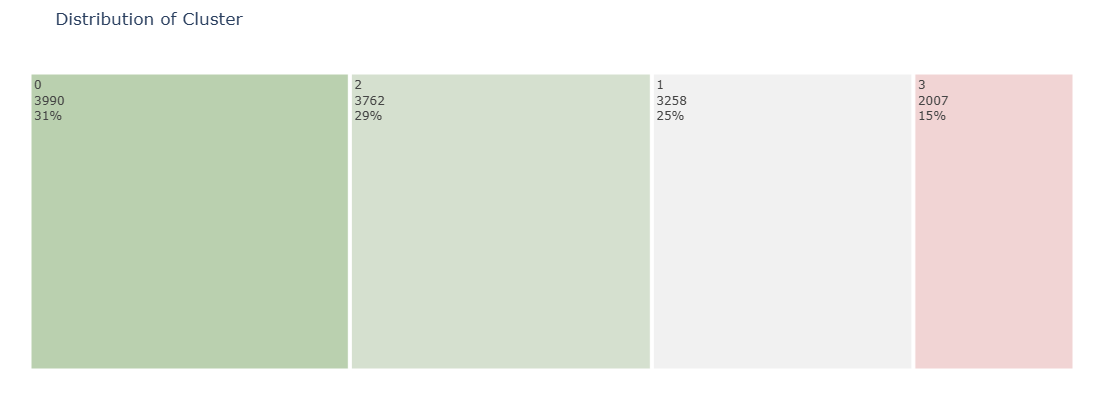

In [ ]:
#Creating a Treemap with Plotly Express
# u need to install plotly

import plotly.express as px

colors = ['#bad0af', '#d5e0cf', '#f1f1f1', '#f1d4d4']  # color palette

fig = px.treemap(
    fig3,  # <- This is a DataFrame
    path=['Cluster'],  # Categorical hierarchy
    values='Count',    # Size of each block
    width=800,
    height=400,
    title="Distribution of Cluster"
)

fig.update_layout(
    treemapcolorway=colors,
    margin=dict(t=50, l=25, r=25, b=25)
)

fig.data[0].textinfo = 'label+text+value+percent root'
fig.show()


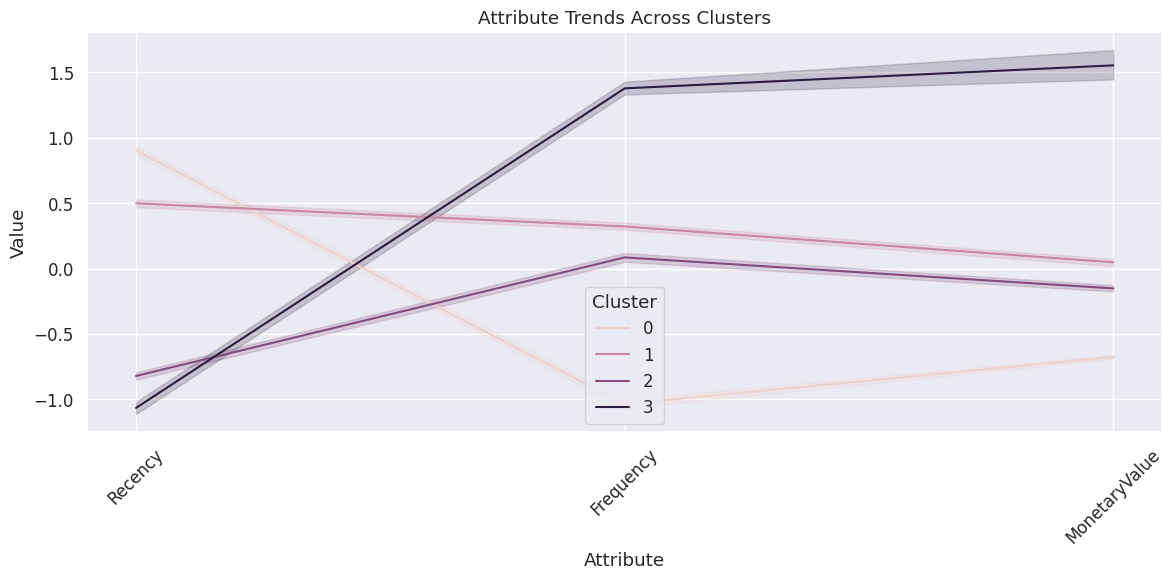

In [ ]:
# Visualization
#sns.lineplot('Attribute', 'Value', hue='Cluster', data=df_nor_melt)

plt.figure(figsize=(12, 6))
sns.lineplot(x='Attribute', y='Value', hue='Cluster', data=df_nor_melt)
plt.title('Attribute Trends Across Clusters')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From the above snake plot, we can see the distribution of recency, frequency, and monetary metric values across the four clusters.
The four clusters seem to be separate from each other, which indicates a good heterogeneous mix of clusters.

In [ ]:
import pandas as pd

#  Aggregate actual cluster sizes
fig3 = df_nor_melt.groupby('Cluster').agg({'ID': 'count'}).reset_index()
fig3.rename(columns={'ID': 'Count'}, inplace=True)
fig3['% of Total'] = ((fig3['Count'] / fig3['Count'].sum()) * 100).round(1).astype(str) + '%'

# Define updated cluster profiling table (without hardcoded %)
cluster_profile = pd.DataFrame({
    'Cluster': [0, 1, 2, 3],
    'Type of Customers': [
        'Lost / Churned Customers',
        'Regular / Mid-Tier Customers',
        'New / Potential Loyalists',
        'Champions / High-Value Customers'
    ],
    'RFM Interpretation': [
        'Inactive for a long time, rarely purchase, and spend little. Likely churned.',
        'Moderately active and moderately spending. Can be nurtured into loyalists.',
        'Recently active with decent frequency and spend. Likely to become loyal.',
        'Very recent, very frequent, and high spenders. Best customers.'
    ]
})

# Merge actual % of Total from fig3
cluster_profile = cluster_profile.merge(fig3[['Cluster', '% of Total']], on='Cluster', how='left')

#Display nicely
summary_df = pd.DataFrame(cluster_profile)
display(summary_df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap'
}).set_table_styles([{
    'selector': 'th',
    'props': [('text-align', 'left')]
}]))


,Cluster,Type of Customers,RFM Interpretation,% of Total
0,0,Lost / Churned Customers,"Inactive for a long time, rarely purchase, and spend little. Likely churned.",30.7%
1,1,Regular / Mid-Tier Customers,Moderately active and moderately spending. Can be nurtured into loyalists.,25.0%
2,2,New / Potential Loyalists,Recently active with decent frequency and spend. Likely to become loyal.,28.9%
3,3,Champions / High-Value Customers,"Very recent, very frequent, and high spenders. Best customers.",15.4%


In [ ]:
# Comparing population vs clusters

## Cluster profiling

In [ ]:
# Recency: Smaller = more recently active
# Frequency: Higher = more purchases = loyalty
# Monetary: Higher = bigger spenders

In [ ]:

# Comparing the difference of rfm between population (count) and clusters
rfm.groupby('Cluster').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'MonetaryValue':['mean', 'count']}).round(1)


Recency Frequency MonetaryValue      
           mean      mean          mean count
Cluster                                      
0         184.9      13.2         315.2  1330
1         112.7      75.0        1244.2  1086
2          19.5      60.0         903.8  1254
3          16.4     524.1       11567.0   669

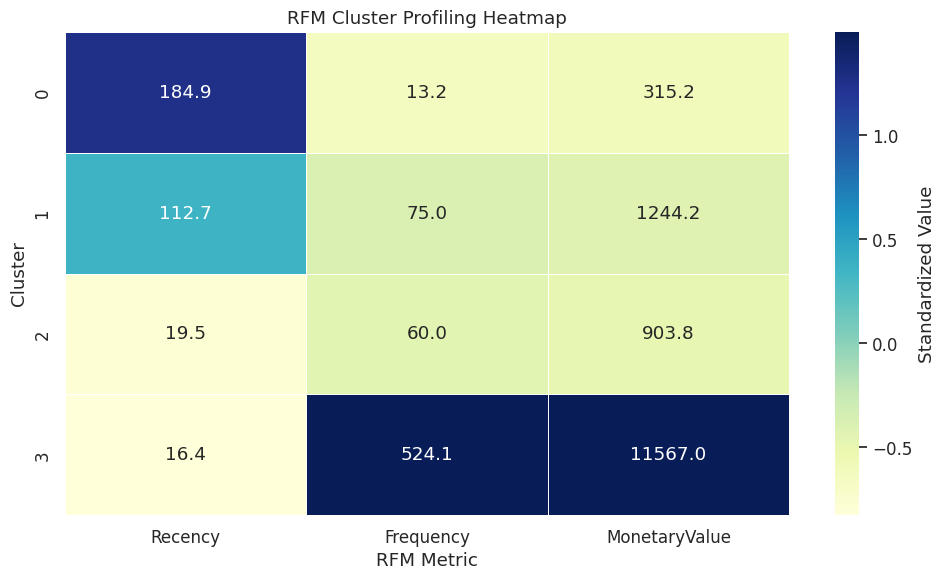

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Group by Cluster and compute mean
rfm_cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'MonetaryValue': 'mean'
}).round(1)

# Optional: Normalize for better color contrast
rfm_normalized = (rfm_cluster_profile - rfm_cluster_profile.mean()) / rfm_cluster_profile.std()

# Step 2: Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(rfm_normalized,
            annot=rfm_cluster_profile,  # show actual means
            fmt='.1f',
            cmap='YlGnBu',
            linewidths=0.5,
            cbar_kws={'label': 'Standardized Value'})

plt.title("RFM Cluster Profiling Heatmap")
plt.ylabel("Cluster")
plt.xlabel("RFM Metric")
plt.tight_layout()
plt.show()


In [ ]:
# Cluster profiling using relative importance scores

# a common technique in customer segmentation (like RFM clustering)
# to compare how each cluster behaves differently from the overall population.

# Step 1: Select only numeric columns
rfm_numeric = rfm.select_dtypes(include='number')

# Step 2: Group by cluster and compute means
cluster_avg = rfm_numeric.groupby(rfm['Cluster']).mean()
# rfm_numeric = rfm.select_dtypes(include='number').drop(columns=['Cluster'])


# Step 3: Compute population mean across all rows
population_avg = rfm_numeric.mean()

# Step 4: Relative importance
relative_imp = cluster_avg / population_avg - 1
relative_imp



# A value of 0.50 → the cluster has a 50% higher average value than the population.
# A value of -0.50 → the cluster has a 50% lower average value.

# Positive values → Cluster has higher average than population
# Negative values → Cluster has lower average than population


,Recency,Frequency,MonetaryValue,Cluster,R,F,M,RFM_Score,RFM_Total
Cluster,,,,,,,,,
0,0.987613,-0.890905,-0.871506,-1.000000,-0.422884,-0.519365,-0.444361,-0.462026,-0.462026
1,0.210803,-0.379999,-0.492701,-0.225317,-0.254634,0.192402,0.148557,0.028137,0.028137
2,-0.790392,-0.504045,-0.631500,0.549366,0.410625,0.053816,-0.000266,0.155181,0.155181
3,-0.824075,3.332817,3.716110,1.324049,0.484372,0.619316,0.642750,0.581975,0.581975


In [ ]:
import pandas as pd

# STEP 1: Compute relative importance as you've done
rfm_numeric = rfm.select_dtypes(include='number')
cluster_avg = rfm_numeric.groupby(rfm['Cluster']).mean()
population_avg = rfm_numeric.mean()
relative_imp = cluster_avg / population_avg - 1

# STEP 2: Define a helper function to classify relative values
def interpret_feature(val, feature):
    direction = "↑" if val > 0.2 else ("↓" if val < -0.2 else "→")
    interpretation = {
        '↑': f"High {feature}",
        '↓': f"Low {feature}",
        '→': f"Average {feature}"
    }
    return interpretation[direction]

# STEP 3: Build a table of interpretation for each cluster
interpretation_table = []
for cluster in relative_imp.index:
    recency = interpret_feature(relative_imp.loc[cluster, 'Recency'], "Recency")
    frequency = interpret_feature(relative_imp.loc[cluster, 'Frequency'], "Frequency")
    monetary = interpret_feature(relative_imp.loc[cluster, 'MonetaryValue'], "MonetaryValue")

    summary = ""
    if "High" in recency and "High" in frequency and "High" in monetary:
        summary = "Champions / High-Value Customers"
    elif "Low" in recency and "Low" in frequency and "Low" in monetary:
        summary = "Churned / Lost Customers"
    elif "High" in recency and ("Low" in frequency or "Low" in monetary):
        summary = "Inactive / At-Risk Customers"
    elif "Low" in recency and ("Average" in frequency or "Average" in monetary):
        summary = "New / Potential Loyalists"
    else:
        summary = "Mid-Tier / Regular Customers"

    interpretation_table.append({
        'Cluster': cluster,
        'Recency': recency,
        'Frequency': frequency,
        'Monetary': monetary,
        'Customer Type': summary
    })

# STEP 4: Create DataFrame and display
interpretation_df = pd.DataFrame(interpretation_table)
display(interpretation_df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap'
}).set_table_styles([{
    'selector': 'th',
    'props': [('text-align', 'left')]
}]))


,Cluster,Recency,Frequency,Monetary,Customer Type
0,0,High Recency,Low Frequency,Low MonetaryValue,Inactive / At-Risk Customers
1,1,High Recency,Low Frequency,Low MonetaryValue,Inactive / At-Risk Customers
2,2,Low Recency,Low Frequency,Low MonetaryValue,Churned / Lost Customers
3,3,Low Recency,High Frequency,High MonetaryValue,Mid-Tier / Regular Customers


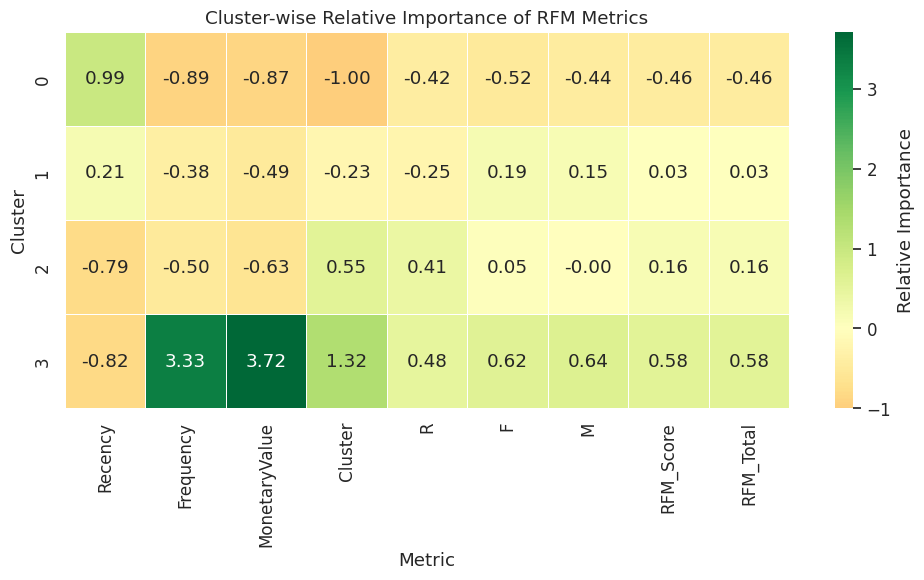

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(relative_imp,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            linewidths=0.5,
            cbar_kws={'label': 'Relative Importance'})

plt.title("Cluster-wise Relative Importance of RFM Metrics")
plt.ylabel("Cluster")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()


In [ ]:
Relative Importance: A value of +0.5 means the cluster's average for that metric is 50% higher than the overall average.
A value of -0.3 means it's 30% below average.

Color Intuition:

Green: Higher than population average
Red: Lower than average
Yellow: Close to average


SyntaxError: unterminated string literal (detected at line 1) (3208908441.py, line 1)

# Scatter Plot
The scatter plot is the data analysis method we use when we have more than two variables.
Remove the outlier from the plot to create a clear visualization result. Those outliers are taken into consideration in the model development.
Exclude them only for visualization purposes.

In [ ]:
rfm_fig = rfm.copy()

#Removing the outlier for visualization
y1 = rfm_fig['Frequency']
size = rfm_fig.shape[0]
removed_outliers = y1.between(y1.quantile(.05), y1.quantile(.95))
print(str(y1[removed_outliers].size) + "/" + str(size) + " data points remain.")
index_names = rfm_fig[~removed_outliers].index
rfm_fig.drop(index_names, inplace=True)

#Removing the outlier for visualization
y2 = rfm_fig['Recency']
size = rfm_fig.shape[0]
removed_outliers = y2.between(y2.quantile(.05), y2.quantile(.95))
print(str(y2[removed_outliers].size) + "/" + str(size) + " data points remain.")
index_names = rfm_fig[~removed_outliers].index
rfm_fig.drop(index_names, inplace=True)

#Removing the outlier for visualization
y3 = rfm_fig['MonetaryValue']
size = rfm_fig.shape[0]
removed_outliers = y3.between(y3.quantile(.05), y3.quantile(.95))
print(str(y3[removed_outliers].size) + "/" + str(size) + " data points remain.")
index_names = rfm_fig[~removed_outliers].index
rfm_fig.drop(index_names, inplace=True)

3943/4339 data points remain.
3581/3943 data points remain.
3223/3581 data points remain.


# Recency Vs frequency



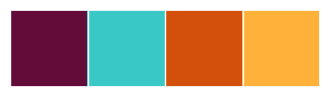

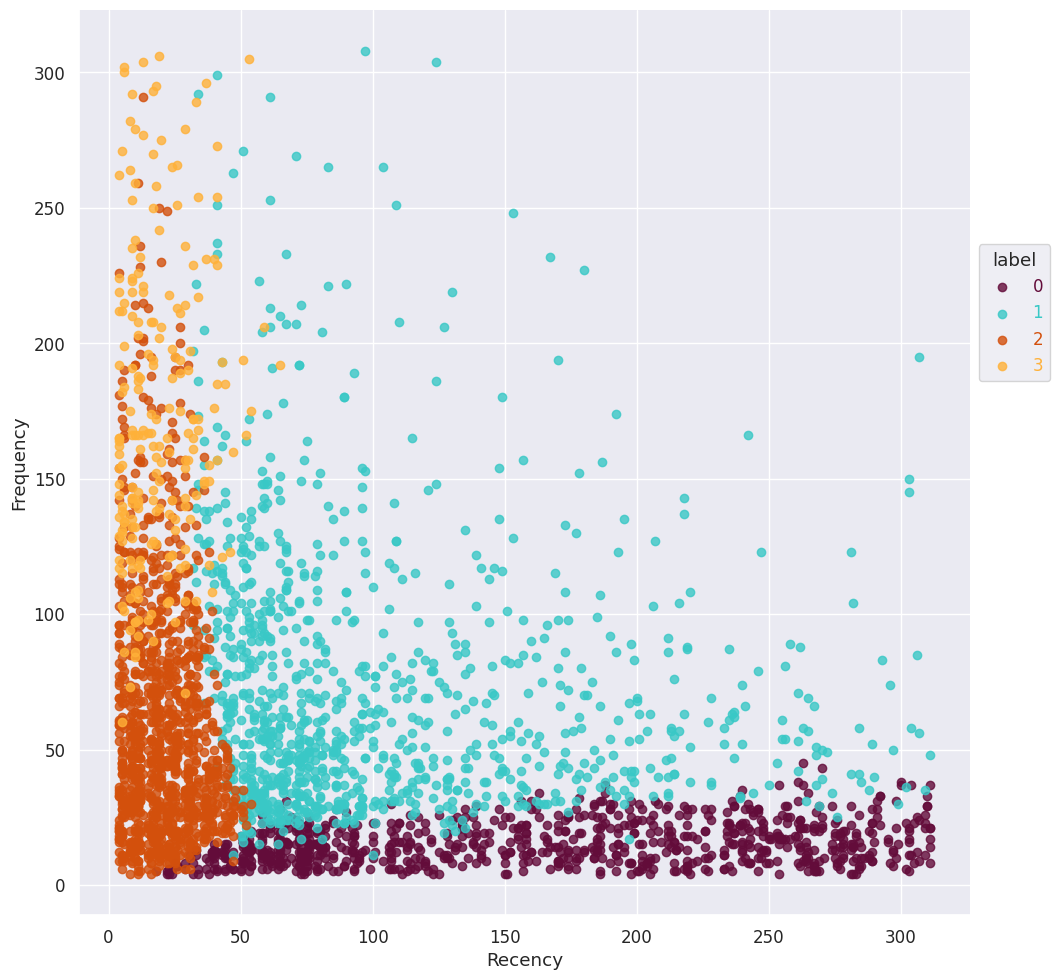

In [ ]:
#defining a custom palette
customPalette = ['#630C3A', '#39C8C6', '#D3500C', '#FFB139']
sns.set_palette(customPalette)
sns.palplot(customPalette)

data = pd.DataFrame(data=rfm_fig,columns=['Customer ID','Cluster','Recency','Frequency','MonetaryValue'])

#plot data with seaborn (don't add a legend yet)
facet = sns.lmplot(data=data, x='Recency', y='Frequency', hue='Cluster', height=10,
                   fit_reg=False, legend=False)

#add a legend
leg = facet.ax.legend(bbox_to_anchor=[1, 0.75],
                         title="label", fancybox=True)
#change colors of labels
for i, text in enumerate(leg.get_texts()):
    plt.setp(text, color = customPalette[i])

## COMMENT: A high frequency is found with customers who have a recent purchase within a month.

Any other comments people ?

# Frequency Vs Monetary

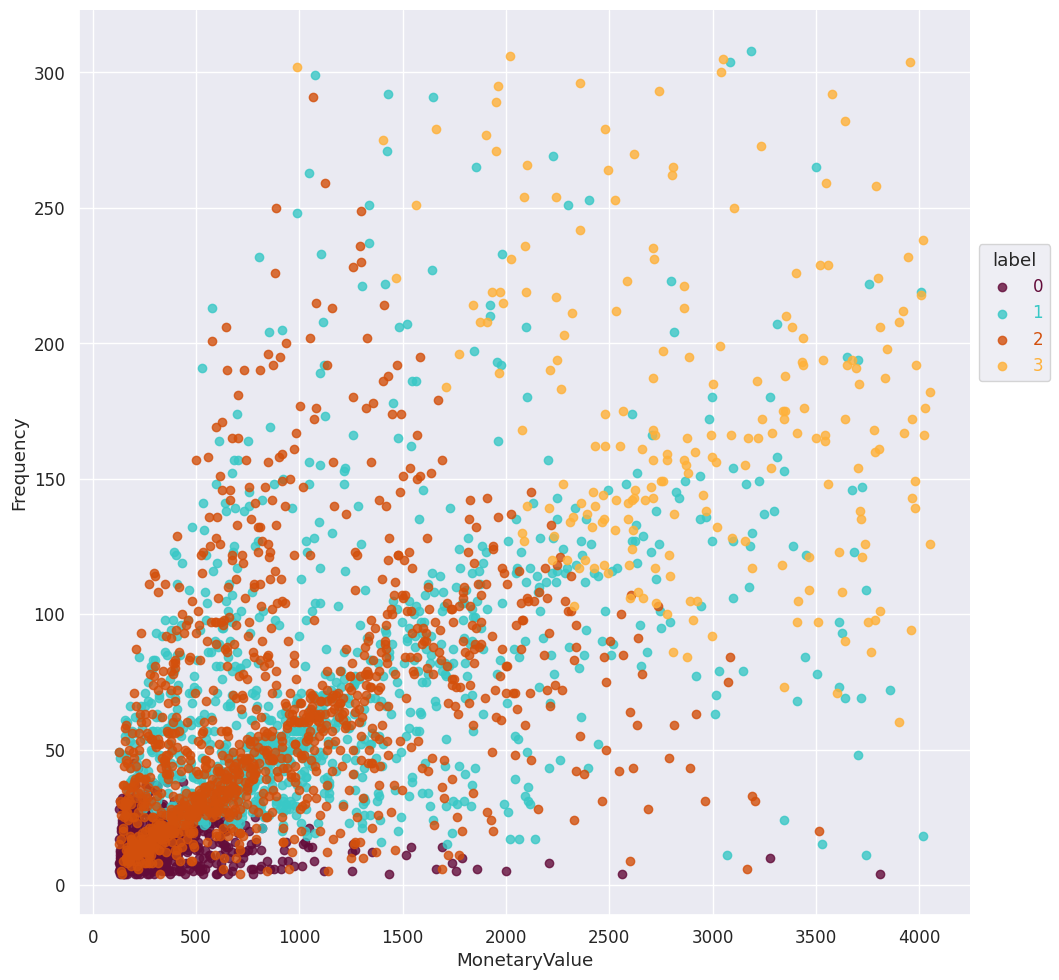

In [ ]:
# fig, ax = plt.subplots(figsize=(10, 8))
#plot data with seaborn (don't add a legend yet)
facet = sns.lmplot(data=data, x='MonetaryValue', y='Frequency', hue='Cluster', height=10,
                   fit_reg=False, legend=False)

#add a legend
leg = facet.ax.legend(bbox_to_anchor=[1, 0.75],
                         title="label", fancybox=True)
#change colors of labels
for i, text in enumerate(leg.get_texts()):
    plt.setp(text, color = customPalette[i])

##  Comment: Customers who buy frequently spend more money.
Any other comments ?

# Recency Vs Frequency Vs Monetary

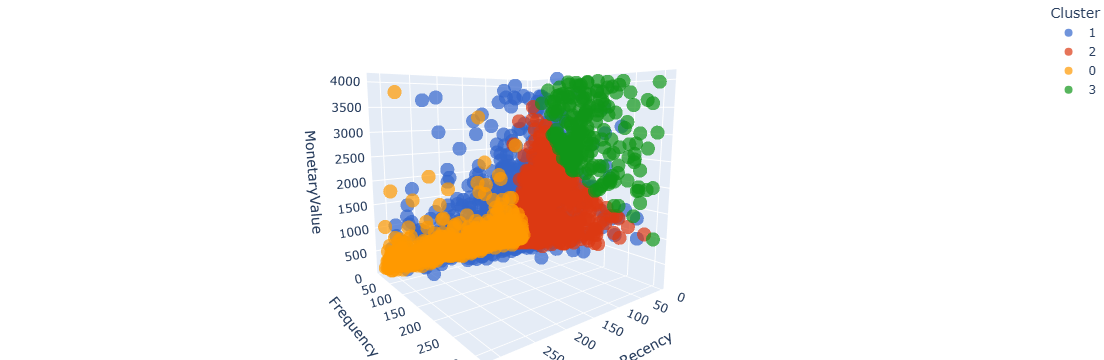

In [ ]:
rfm_fig['Cluster'] = rfm_fig['Cluster'].astype(str)

import plotly.express as px
fig = px.scatter_3d(rfm_fig,x='Recency', y='Frequency', z='MonetaryValue',
              color='Cluster', opacity=0.7,color_discrete_sequence=px.colors.qualitative.G10)

fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))
fig.show()

In [ ]:
cluster_avg1 = rfm[['Cluster','Recency','Frequency','MonetaryValue']].groupby(['Cluster']).mean()
population_avg1 = rfm[['Recency','Frequency','MonetaryValue']].head().mean()

In [ ]:
cluster_avg1

,Recency,Frequency,MonetaryValue
Cluster,,,
0,184.924060,13.196992,315.152294
1,112.651013,75.000000,1244.234753
2,19.501595,59.994418,903.805814
3,16.367713,524.130045,11567.035605


In [ ]:
population_avg1

Recency            147.000
Frequency           60.800
MonetaryValue    17076.558
dtype: float64

In [ ]:
relative_imp1 = cluster_avg1 / population_avg1 - 1
relative_imp1.round(2)

,Recency,Frequency,MonetaryValue
Cluster,,,
0,0.26,-0.78,-0.98
1,-0.23,0.23,-0.93
2,-0.87,-0.01,-0.95
3,-0.89,7.62,-0.32


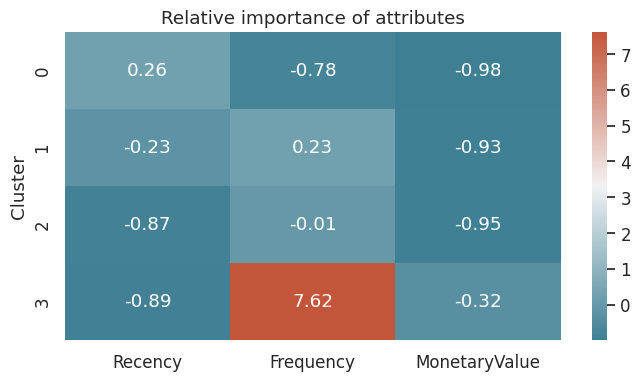

In [ ]:
cmap = sns.diverging_palette(220, 20, as_cmap=True)
# Plot heatmap
plt.figure(figsize=(8, 4))
plt.title('Relative importance of attributes')
sns.heatmap(data=relative_imp1, annot=True, fmt='.2f', cmap=cmap)
plt.show()

# Interpret the result
From the above analysis, we can see that there should be 4 clusters in our data. To understand what these 4 clusters mean in a business scenario, we should look back the table comparing the clustering performance of 3 and 4 clusters for the mean values of recency, frequency, and monetary metric.

Below is the table giving the RFM interpretation of each segment and please do remember the points that a company is recommended to keep in mind while designing the marketing strategy for that segment of customers.

| Cluster | Recency | Frequency | Monetary | Summary                                                                                             |
| ------- | ------- | --------- | -------- | --------------------------------------------------------------------------------------------------- |
| 0       | +0.26   | -0.78     | -0.98    | Recency a bit old, low frequency, low spend. Passive or fading buyers.                              |
| 1       | -0.23   | +0.23     | -0.93    | Somewhat recent, decent activity, but low spend. Active but low-value.                              |
| 2       | -0.87   | -0.01     | -0.95    | Very recent but not engaged. Possibly trial users or low conversion.                                |
| 3       | -0.89   | +7.62     | -0.32    | Very recent and extremely frequent, spend is still lower than avg. VIPs or service-heavy customers. |


The ranking of the individual RFM scores is done by dividing each of the RFM values into quartiles which creates four more or less equal buckets. We then rank each bucket from one to four; four being the best. Our summary table should now look something like this:

In [ ]:
# Check column data types
print(rfm.dtypes)

# Convert to numeric if needed
rfm['Recency'] = pd.to_numeric(rfm['Recency'], errors='coerce')
rfm['Frequency'] = pd.to_numeric(rfm['Frequency'], errors='coerce')
rfm['MonetaryValue'] = pd.to_numeric(rfm['MonetaryValue'], errors='coerce')

#  Drop rows with NaNs
rfm = rfm.dropna(subset=['Recency', 'Frequency', 'MonetaryValue'])

quantiles = rfm[['Recency', 'Frequency', 'MonetaryValue']].quantile(q=[0.2, 0.4, 0.6, 0.8])

# Ensure the outer keys are columns, and inner keys are floats (0.2, 0.4, etc.)
quantiles = {col: quantiles[col].to_dict() for col in quantiles.columns}

# quantiles = rfm.quantile(q=[0.2,0.4,0.6,0.8])
# quantiles = quantiles.to_dict()

def RScore(x, p, d):
    if x <= d[p][0.2]:
        return 5
    elif x <= d[p][0.4]:
        return 4
    elif x <= d[p][0.6]:
        return 3
    elif x <= d[p][0.8]:
        return 2
    else:
        return 1

def FMScore(x, p, d):
    if x <= d[p][0.2]:
        return 1
    elif x <= d[p][0.4]:
        return 2
    elif x <= d[p][0.6]:
        return 3
    elif x <= d[p][0.8]:
        return 4
    else:
        return 5

# Apply scoring
rfm['R'] = rfm['Recency'].apply(RScore, args=('Recency', quantiles,))
rfm['F'] = rfm['Frequency'].apply(FMScore, args=('Frequency', quantiles,))
rfm['M'] = rfm['MonetaryValue'].apply(FMScore, args=('MonetaryValue', quantiles,))


CustomerID        object
Recency            int64
Frequency          int64
MonetaryValue    float64
Cluster            int32
R                  int64
F                  int64
M                  int64
RFM_Segment       object
RFM_Score          int64
SegmentCode       object
Segment           object
RFM_Total          int64
Score             object
dtype: object


In [ ]:
# Concat RFM quartile values to create RFM Segments
def join_rfm(x): return str(x['R']) + str(x['F']) + str(x['M'])
rfm['RFM_Segment'] = rfm.apply(join_rfm, axis=1)
# Calculate RFM_Score
rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis=1)

In [ ]:
rfm['RFM_Segment'].unique()

array(['115', '555', '234', '444', '122', '345', '111', '144', '112',
       '445', '355', '524', '223', '544', '123', '511', '344', '334',
       '433', '522', '255', '233', '423', '442', '244', '324', '455',
       '312', '245', '333', '323', '554', '133', '545', '235', '411',
       '322', '211', '422', '325', '533', '534', '222', '214', '155',
       '412', '121', '224', '331', '134', '311', '421', '434', '343',
       '435', '512', '353', '321', '145', '413', '432', '225', '232',
       '535', '523', '543', '253', '114', '515', '335', '443', '231',
       '313', '212', '143', '514', '431', '213', '243', '124', '552',
       '414', '113', '454', '221', '424', '132', '513', '354', '532',
       '342', '131', '453', '341', '521', '541', '141', '142', '553',
       '531', '254', '215', '242', '332', '525', '153', '542', '315',
       '135', '154', '152', '125', '352', '241', '314', '441', '415',
       '425'], dtype=object)

# Grouping and labelling with RFM label

For the RFM segment we are going to use the most common naming scheme, as outlined abo

In [ ]:
# Step 1: Combine R and F scores into a two-digit code (as string)
rfm['SegmentCode'] = rfm['R'].astype(str) + rfm['F'].astype(str)

# Step 2: Define the segment map (regex patterns)
segt_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At risk',
    r'[1-2]5': "Can't lose them",
    r'3[1-2]': 'About to sleep',
    r'33': 'Need attention',
    r'[3-4][4-5]': 'Loyal customers',
    r'41': 'Promising',
    r'51': 'New customers',
    r'[4-5][2-3]': 'Potential loyalists',
    r'5[4-5]': 'Champions'
}

# Step 3: Apply the human-readable segment labels using regex
rfm['Segment'] = rfm['SegmentCode'].replace(segt_map, regex=True)

# Step 4: Create RFM Total score
rfm['RFM_Total'] = rfm['R'] + rfm['F'] + rfm['M']

# Step 5: Score bands (Green, Bronze, Silver, Gold, Platinum)
rfm['Score'] = 'Green'
rfm.loc[rfm['RFM_Total'] > 5, 'Score'] = 'Bronze'
rfm.loc[rfm['RFM_Total'] > 7, 'Score'] = 'Silver'
rfm.loc[rfm['RFM_Total'] > 9, 'Score'] = 'Gold'
rfm.loc[rfm['RFM_Total'] > 11, 'Score'] = 'Platinum'

# Step 6: View top rows
rfm.head()


,CustomerID,Recency,Frequency,MonetaryValue,Cluster,R,F,M,RFM_Segment,RFM_Score,SegmentCode,Segment,RFM_Total,Score
0,12346.0,326,1,77183.60,3,1,1,5,115,7,11,Hibernating,7,Bronze
1,12347.0,3,182,4310.00,3,5,5,5,555,15,55,Champions,15,Platinum
2,12348.0,76,31,1797.24,1,2,3,4,234,9,23,At risk,9,Silver
3,12349.0,19,73,1757.55,2,4,4,4,444,12,44,Loyal customers,12,Platinum
4,12350.0,311,17,334.40,0,1,2,2,122,5,12,Hibernating,5,Green


In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")

In [ ]:
rfm.head()


,CustomerID,Recency,Frequency,MonetaryValue,Cluster,R,F,M,RFM_Segment,RFM_Score,SegmentCode,Segment,RFM_Total,Score
0,12346.0,326,1,77183.60,3,1,1,5,115,7,11,Hibernating,7,Bronze
1,12347.0,3,182,4310.00,3,5,5,5,555,15,55,Champions,15,Platinum
2,12348.0,76,31,1797.24,1,2,3,4,234,9,23,At risk,9,Silver
3,12349.0,19,73,1757.55,2,4,4,4,444,12,44,Loyal customers,12,Platinum
4,12350.0,311,17,334.40,0,1,2,2,122,5,12,Hibernating,5,Green


In [ ]:
fig1 = rfm.groupby(['Segment']).count().unstack().fillna(0)
fig2 = rfm.groupby(['Score']).count().unstack().fillna(0)

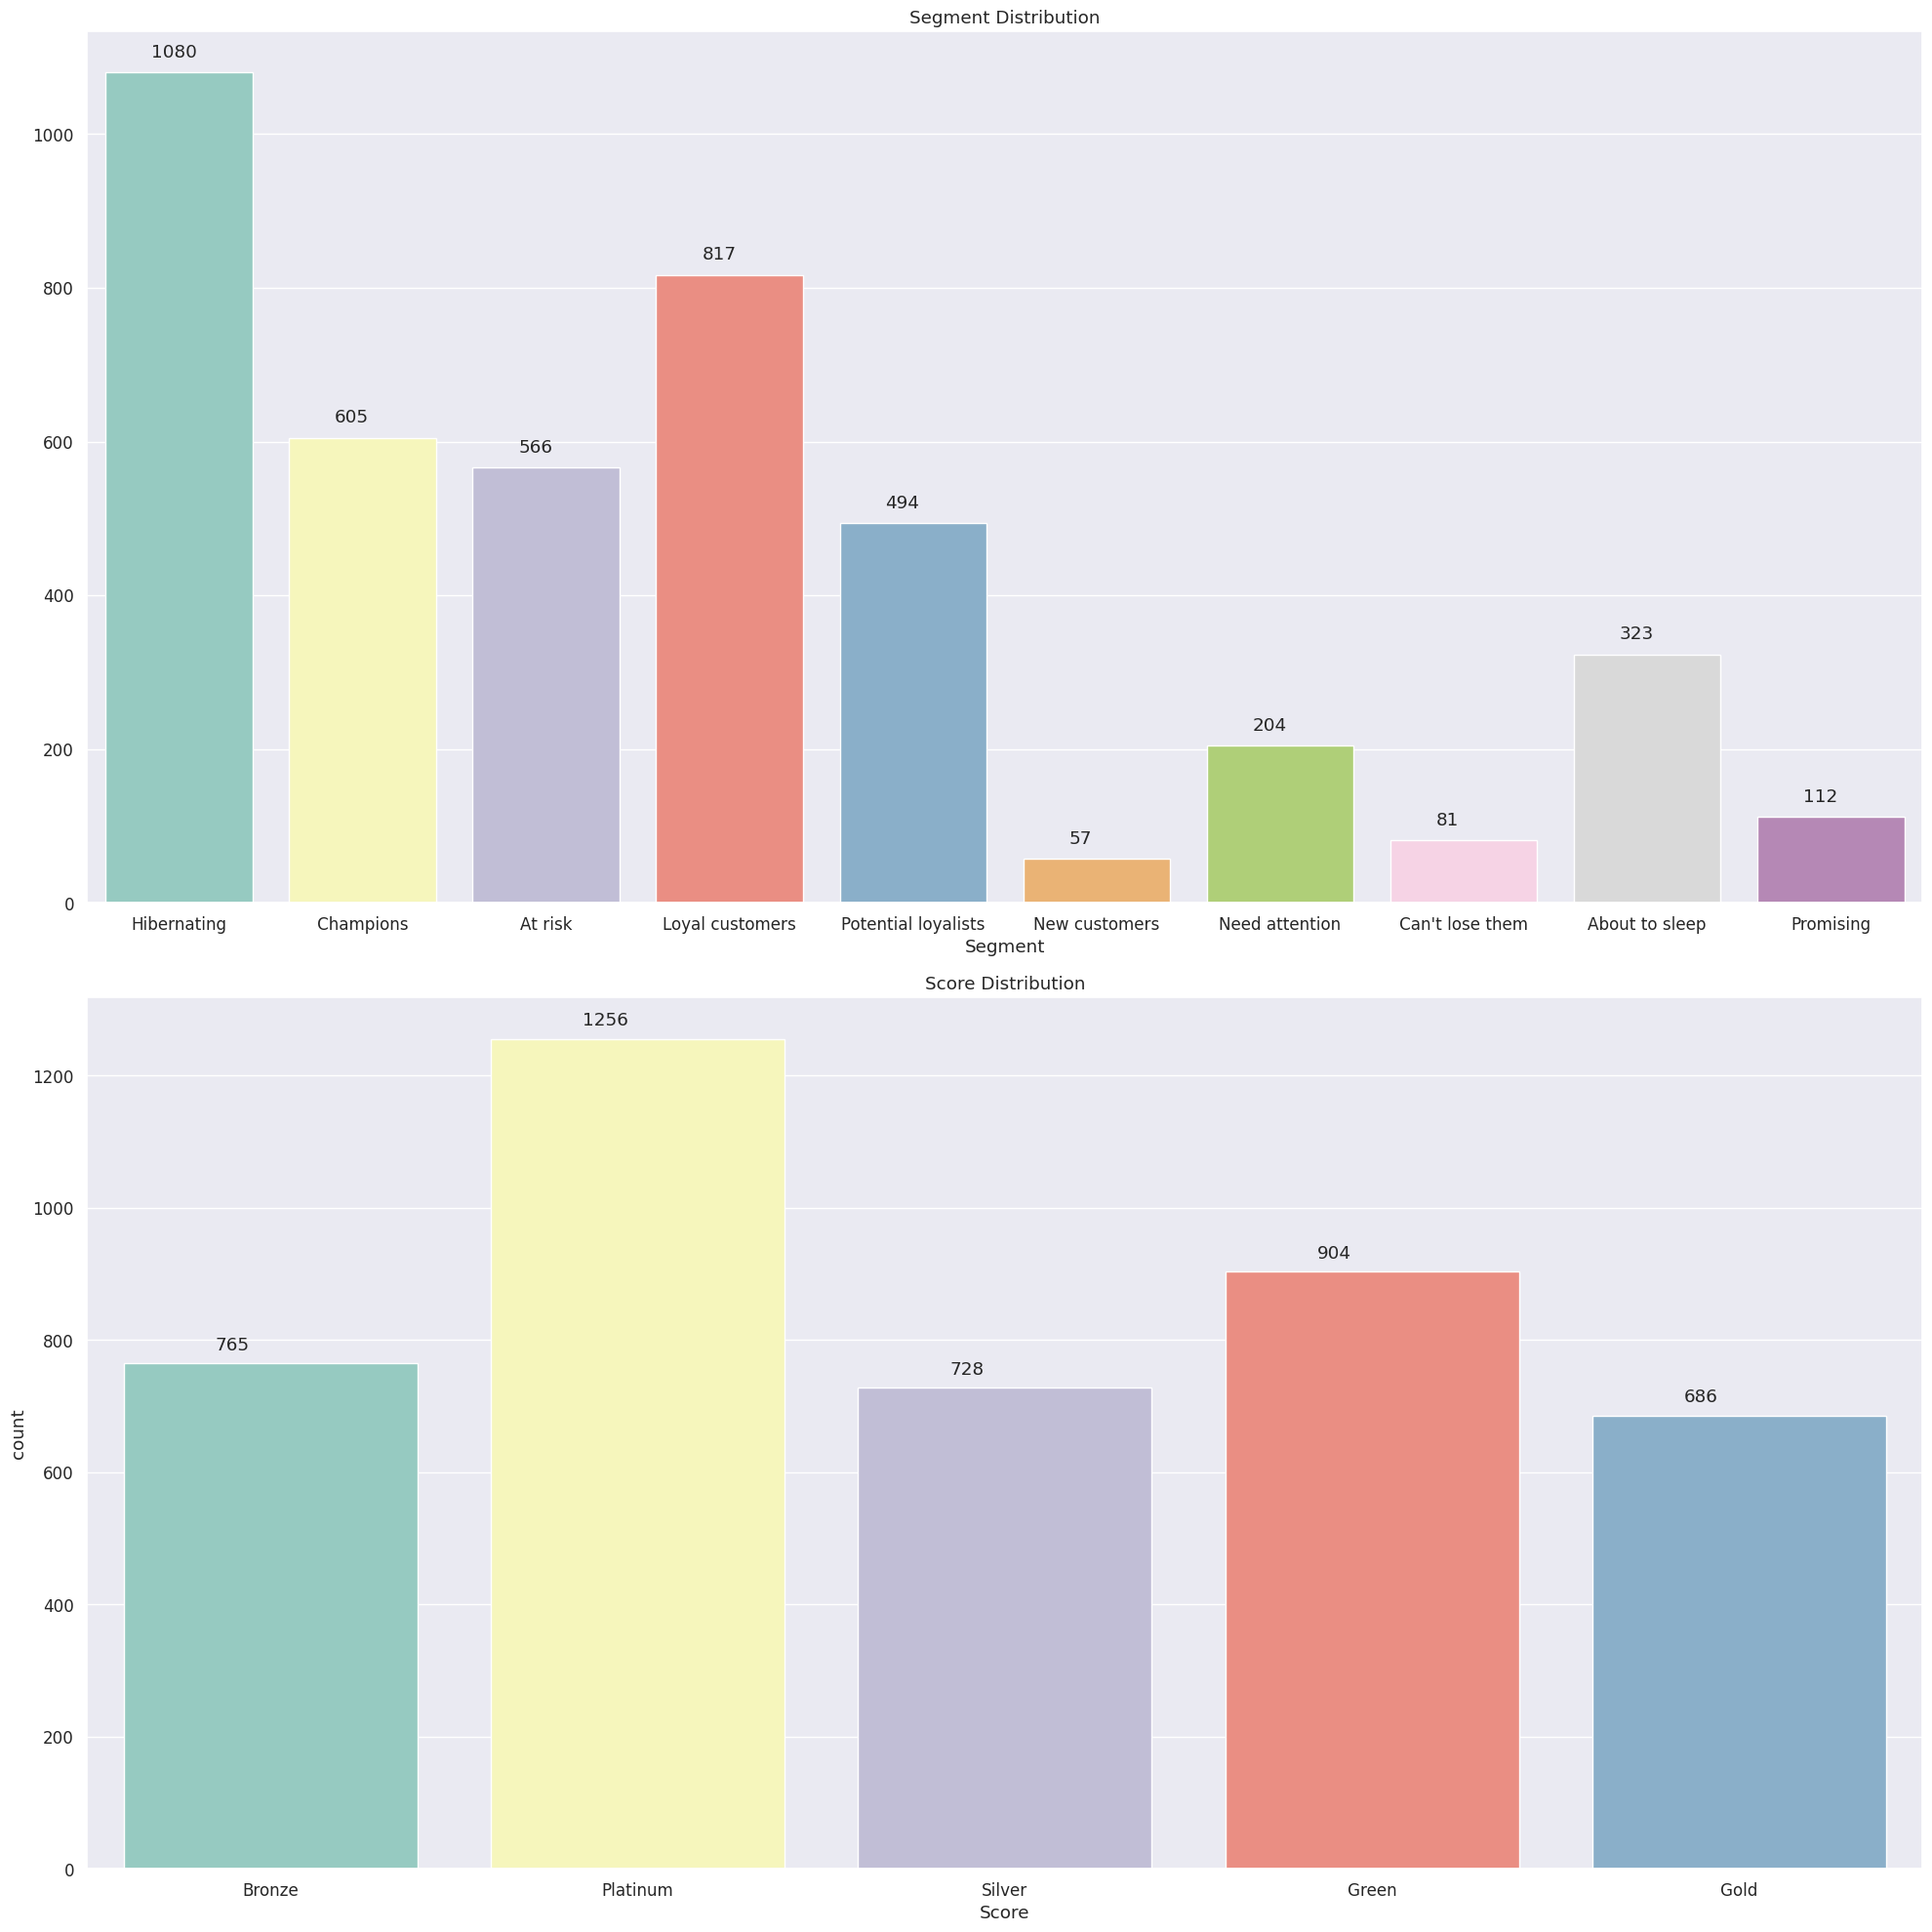

In [ ]:

sns.set(font_scale=1.1)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(font_scale=1.1)

# Plot
f, ax = plt.subplots(2, 1, figsize=(20, 20))

# Bar plot by Segment
sns.countplot(x='Segment', data=rfm, ax=ax[0], palette="Set3")
ax[0].set_title('Segment Distribution')
ax[0].set_ylabel('')

# Bar plot by Score
sns.countplot(x='Score', data=rfm, ax=ax[1], palette="Set3")
ax[1].set_title('Score Distribution')

# Annotate bars
for p in ax[0].patches:
    ax[0].annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+20))

for p in ax[1].patches:
    ax[1].annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.25, p.get_height()+20))

plt.tight_layout()
plt.show()


In [ ]:
# Aggregate data by each customer
fig3 = rfm.groupby('Segment').agg({'CustomerID': lambda x: len(x)}).reset_index()

# Rename columns
fig3.rename(columns={'CustomerID': 'Count'}, inplace=True)
fig3['percent'] = (fig3['Count'] / fig3['Count'].sum()) * 100
fig3['percent'] = fig3['percent'].round(1)

fig3

,Segment,Count,percent
0,About to sleep,323,7.4
1,At risk,566,13.0
2,Can't lose them,81,1.9
3,Champions,605,13.9
4,Hibernating,1080,24.9
5,Loyal customers,817,18.8
6,Need attention,204,4.7
7,New customers,57,1.3
8,Potential loyalists,494,11.4
9,Promising,112,2.6


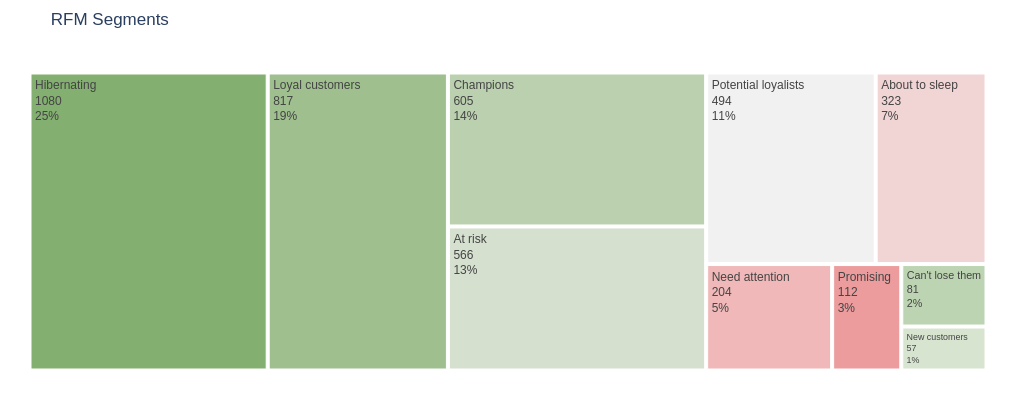

In [ ]:
#Creating a Treemap with Plotly Express
# colors=['#fae588','#f79d65','#f9dc5c','#e8ac65','#e76f51','#ef233c','#b7094c'] #color palette
colors=['#83af70','#9fbf8f','#bad0af','#d5e0cf','#f1f1f1','#f1d4d4','#f0b8b8','#ec9c9d'] #color palette
import plotly.express as px

fig = px.treemap(fig3, path=['Segment'],values='Count'
                 , width=800, height=400
                 ,title="RFM Segments")

fig.update_layout(
    treemapcolorway = colors, #defines the colors in the treemap
    margin = dict(t=50, l=25, r=25, b=25))

fig.data[0].textinfo = 'label+text+value+percent root'
fig.show()

In [ ]:
# Aggregate data by each customer
fig4 = rfm.groupby('Score').agg({'CustomerID': lambda x: len(x)}).reset_index()


# Rename columns
fig4.rename(columns={'CustomerID': 'Count'}, inplace=True)
fig4['percent'] = (fig4['Count'] / fig4['Count'].sum()) * 100
fig4['percent'] = fig4['percent'].round(1)

fig4.head()

,Score,Count,percent
0,Bronze,765,17.6
1,Gold,686,15.8
2,Green,904,20.8
3,Platinum,1256,28.9
4,Silver,728,16.8


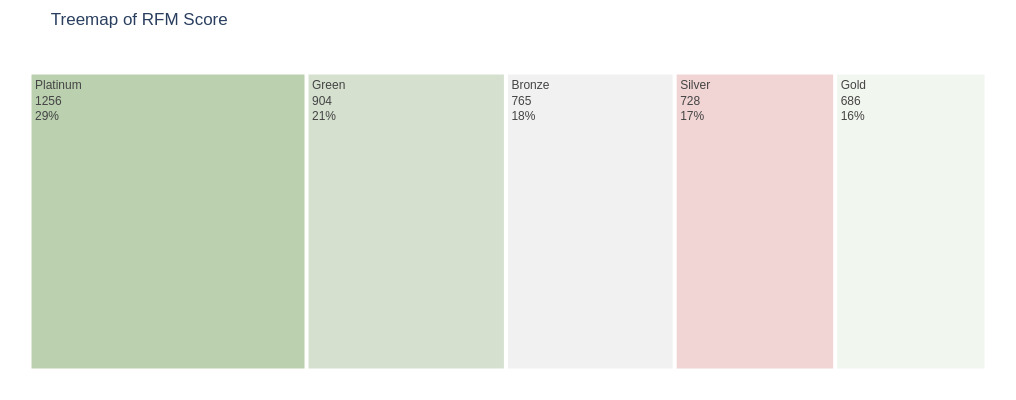

In [ ]:
#Creating a Treemap with Plotly Express
# colors=['#fae588','#f79d65','#f9dc5c','#e8ac65','#e76f51','#ef233c','#b7094c'] #color palette
colors=['#bad0af','#d5e0cf','#f1f1f1','#f1d4d4'] #color palette
import plotly.express as px

fig = px.treemap(fig4, path=['Score'],values='Count'
                 , width=800, height=400
                 ,title="Treemap of RFM Score")

fig.update_layout(
    treemapcolorway = colors, #defines the colors in the treemap
    margin = dict(t=50, l=25, r=25, b=25))

fig.data[0].textinfo = 'label+text+value+percent root'
fig.show()

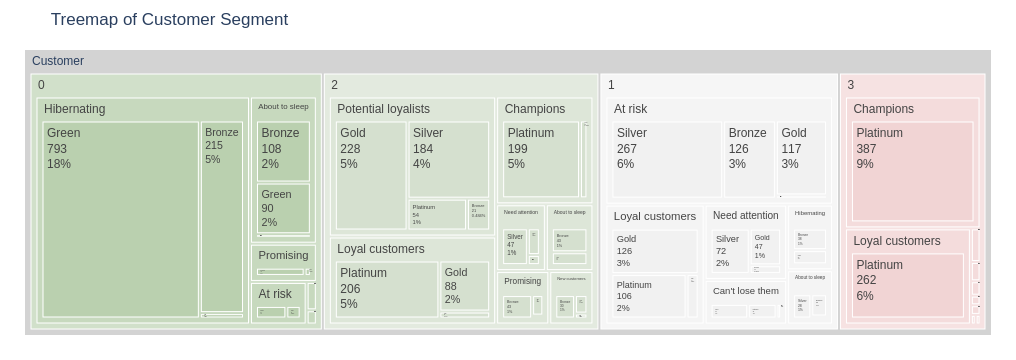

In [ ]:
# Aggregate data by each customer
fig5 = rfm.groupby(['Cluster', 'Segment', 'Score']).agg({'CustomerID': lambda x: len(x)}).reset_index()

# Rename columns
fig5.rename(columns={'CustomerID': 'Count'}, inplace=True)
fig5['percent'] = (fig5['Count'] / fig5['Count'].sum()) * 100
fig5['percent'] = fig5['percent'].round(1)

fig5.head()
colors=['#bad0af','#d5e0cf','#f1f1f1','#f1d4d4'] #color palette
import plotly.express as px
fig = px.treemap(fig5, path=[px.Constant("Customer"), 'Cluster', 'Segment', 'Score'], values='Count'
                ,title="Treemap of Customer Segment")
fig.update_traces(root_color="lightgrey")
fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))

fig.update_layout(
    treemapcolorway = colors, #defines the colors in the treemap
    margin = dict(t=50, l=25, r=25, b=25))

fig.data[0].textinfo = 'label+text+value+percent root'
fig.show()

## Using RFM segment to Interpret the result

In [ ]:
# Aggregate data by each customer
rfm1 = rfm.groupby(['Cluster','Segment'],).agg({'CustomerID': lambda x: len(x)}).reset_index()

# Rename columns
rfm1.rename(columns={'CustomerID': 'Count'}, inplace=True)
rfm1['percent'] = (rfm1['Count'] / rfm1.groupby('Cluster')['Count'].transform('sum')) * 100
rfm1['percent'] = rfm1['percent'].round(1)

rfm1.head()

,Cluster,Segment,Count,percent
0,0,About to sleep,204,15.3
1,0,At risk,50,3.8
2,0,Hibernating,1014,76.2
3,0,Need attention,3,0.2
4,0,New customers,6,0.5


# Step 4 Action to take for retain the customer

Here's a handy chart of all the RFM Segments, and some actionable tips for each which can implement straight away!

What we have learned

In [ ]:
import pandas as pd
from IPython.display import display

# Step 1: Aggregate actual cluster sizes
fig3 = df_nor_melt.groupby('Cluster').agg({'ID': 'count'}).reset_index()
fig3.rename(columns={'ID': 'Count'}, inplace=True)
fig3['% of Total'] = ((fig3['Count'] / fig3['Count'].sum()) * 100).round(1).astype(str) + '%'

# Step 2: Define profiling details
cluster_profile = pd.DataFrame({
    'Cluster': [0, 1, 2, 3],
    'Type of Customers': [
        'Lost / Churned Customers',         # Cluster 0
        'Regular / Mid-Tier Customers',     # Cluster 1
        'New / Potential Loyalists',        # Cluster 2
        'Champions / High-Value Customers'  # Cluster 3
    ],
    'RFM Label': [
        'Mostly Hibernating & At Risk',
        'Majority: Loyal & Promising',
        'New Customers & Warm Leads',
        'Champions, Advocates & Big Spenders'
    ],
    'RFM Interpretation': [
        'Inactive for a long time, rarely purchase, and spend little. Likely churned.',
        'Moderately active and moderately spending. Can be nurtured into loyalists.',
        'Recently active with decent frequency and spend. Likely to become loyal.',
        'Very recent, very frequent, and high spenders. Your best and most loyal customers.'
    ],
    'Actionable Insight': [
        'Win back with reactivation offers or reminder nudges.',
        'Nurture with tailored loyalty programs or product bundles.',
        'Engage early with onboarding nudges and curated deals.',
        'Upsell, cross-sell, and build long-term brand advocacy.'
    ]
})

# Step 3: Merge actual % of total
cluster_profile = cluster_profile.merge(fig3[['Cluster', '% of Total']], on='Cluster', how='left')

# Step 4: Display the final profiling table
display(cluster_profile.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap'
}).set_table_styles([{
    'selector': 'th',
    'props': [('text-align', 'left')]
}]))



,Cluster,Type of Customers,RFM Label,RFM Interpretation,Actionable Insight,% of Total
0,0,Lost / Churned Customers,Mostly Hibernating & At Risk,"Inactive for a long time, rarely purchase, and spend little. Likely churned.",Win back with reactivation offers or reminder nudges.,30.7%
1,1,Regular / Mid-Tier Customers,Majority: Loyal & Promising,Moderately active and moderately spending. Can be nurtured into loyalists.,Nurture with tailored loyalty programs or product bundles.,25.0%
2,2,New / Potential Loyalists,New Customers & Warm Leads,Recently active with decent frequency and spend. Likely to become loyal.,Engage early with onboarding nudges and curated deals.,28.9%
3,3,Champions / High-Value Customers,"Champions, Advocates & Big Spenders","Very recent, very frequent, and high spenders. Your best and most loyal customers.","Upsell, cross-sell, and build long-term brand advocacy.",15.4%


In [ ]:
import pandas as pd
from IPython.display import display

# Define the updated retention strategies based on new cluster definitions
retention_data = {
    'Segment / Cluster': [
        'Champions / High-Value Customers (Cluster 3)',
        'New / Potential Loyalists (Cluster 2)',
        'Regular / Mid-Tier Customers (Cluster 1)',
        'Lost / Churned Customers (Cluster 0)'
    ],
    'Description': [
        'Very recent, very frequent, and high spenders. Most valuable customers.',
        'Recently active with decent frequency and spend. Show promise for long-term loyalty.',
        'Moderately active and moderately spending. Dependable base of regular buyers.',
        'Inactive for a long time, rarely purchase, and spend little. Likely to churn.'
    ],
    'Key Actions to Retain': [
        '''- Prioritize with VIP loyalty programs or early access
- Upsell premium/high-margin products
- Request testimonials or referrals
- Personalized thank-you gestures''',

        '''- Send onboarding nudges and product education
- Offer personalized deals or trial offers
- Track engagement closely and reward consistency
- Nudge into loyalty programs''',

        '''- Cross-sell or bundle offers
- Push seasonal or repeat purchase campaigns
- Segment-specific discount emails
- Keep warm through re-engagement content''',

        '''- Win-back email campaigns with special offers
- Use inactivity-based retargeting ads
- Conduct exit surveys to gather feedback
- Offer deep discounts or urgency-based promotions'''
    ]
}

# Create and display the DataFrame
retention_df = pd.DataFrame(retention_data)

display(retention_df.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap'
}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left')]}
]))


,Segment / Cluster,Description,Key Actions to Retain
0,Champions / High-Value Customers (Cluster 3),"Very recent, very frequent, and high spenders. Most valuable customers.",- Prioritize with VIP loyalty programs or early access - Upsell premium/high-margin products - Request testimonials or referrals - Personalized thank-you gestures
1,New / Potential Loyalists (Cluster 2),Recently active with decent frequency and spend. Show promise for long-term loyalty.,- Send onboarding nudges and product education - Offer personalized deals or trial offers - Track engagement closely and reward consistency - Nudge into loyalty programs
2,Regular / Mid-Tier Customers (Cluster 1),Moderately active and moderately spending. Dependable base of regular buyers.,- Cross-sell or bundle offers - Push seasonal or repeat purchase campaigns - Segment-specific discount emails - Keep warm through re-engagement content
3,Lost / Churned Customers (Cluster 0),"Inactive for a long time, rarely purchase, and spend little. Likely to churn.",- Win-back email campaigns with special offers - Use inactivity-based retargeting ads - Conduct exit surveys to gather feedback - Offer deep discounts or urgency-based promotions


In [ ]:
# Courtesy: Melody Yip, Notenook on UCL dataset [modified it ~ Dr.AMK]